# ICBHI 2017 Respiratory Sound Classification
## DL + ML Pipeline | Level-1 (Healthy/Unhealthy) & Level-2 (Wheeze/Crackle/Both/None)

**Dataset:** `nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database`  
**Pipeline stages:**
1. Install & GPU check
2. Imports & paths
3. Inspect dataset
4. Preprocess audio → 2.5 s segments
5. Build train/test split CSVs
6. DL image generation (Mel-Spectrogram, MFCC, Recurrence Plot)
7. Display sample images (1 per level/sublevel per model)
8. DL models (ResNet18, MobileNetV2) — both levels — with full evaluation metrics & training curves
9. 🆕 **ML models** (RF, ET, XGB, SVM, KNN, LR, DT) — MFCC+RP tabular features
   - All metrics (Acc, F1, Prec, Rec) derived strictly from confusion matrix
   - CV accuracy curves, per-class bars, model comparison, leaderboard
   - Results saved to `ml_results/`
10. Output summary


## ⚙️ Cell 1 — Install Dependencies

In [1]:
%%capture
!pip install -q librosa soundfile scipy pywavelets pyts scikit-learn \
               xgboost lightgbm imbalanced-learn tqdm matplotlib pillow \
               torch torchvision torchaudio


## 🖥️ Cell 2 — GPU Check

In [2]:
import torch
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")


CUDA: True
GPU : Tesla T4
VRAM: 15.6 GB


## 📦 Cell 3 — Imports & Global Config

In [3]:
import os, warnings, multiprocessing
from pathlib import Path
from math import ceil
from datetime import datetime
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ── Dataset path (Kaggle mount) ───────────────────────────────────────────────
DATASET_ROOT = Path("/kaggle/input/icbhi-2017-challenge-respiratory-sound-database")
AUDIO_DIR    = DATASET_ROOT / "ICBHI_final_database"
DIAG_CSV     = Path("/kaggle/input/datasets/santhoshsanka/patient-diagnosis/patient_diagnosis.csv")

# ── Output root ───────────────────────────────────────────────────────────────
OUT          = Path("/kaggle/working/icbhi_dl_pipeline")

# Derived paths
SEG_DIR      = OUT / "segments_wav"
META_CSV     = OUT / "meta.csv"
TRAIN_CSV    = OUT / "splits" / "train.csv"
TEST_CSV     = OUT / "splits" / "test.csv"
IMG_DIR      = OUT / "images"
CKPT_DIR     = OUT / "checkpoints"
REPORT_DIR   = OUT / "reports"

# ── Per-model result folders ──────────────────────────────────────────────────
RESNET_DIR   = REPORT_DIR / "resnet18"
MOBILE_DIR   = REPORT_DIR / "mobilenet_v2"

for d in [SEG_DIR, TRAIN_CSV.parent, IMG_DIR, CKPT_DIR,
          REPORT_DIR, RESNET_DIR, MOBILE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Audio hyper-params ────────────────────────────────────────────────────────
SR           = 4000
LOWCUT       = 50.0
HIGHCUT      = 1800.0
SEG_SEC      = 2.5
OVERLAP      = 0.5
SILENCE_RMS  = 1e-7

# ── DL hyper-params ───────────────────────────────────────────────────────────
TEST_RATIO   = 0.20
SEED         = 42
IMAGE_SIZE   = 128
N_MFCC       = 40
BATCH        = 32
EPOCHS       = 25
LR           = 1e-3

def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}", flush=True)

log(f"Dataset root : {DATASET_ROOT}")
log(f"Output root  : {OUT}")


[03:11:53] Dataset root : /kaggle/input/icbhi-2017-challenge-respiratory-sound-database
[03:11:53] Output root  : /kaggle/working/icbhi_dl_pipeline


## 🔍 Cell 4 — Inspect Dataset & Auto-detect Paths

In [4]:

import glob
import pandas as pd

# 1. Audio Data Paths
DATASET_ROOT = Path("/kaggle/input/datasets/nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database")
AUDIO_DIR    = DATASET_ROOT / "ICBHI_final_database"

# 2. Diagnosis File Path 
# We add the filename 'patient_diagnosis.csv' to the end of the directory path
DIAG_CSV = Path("/kaggle/input/datasets/santhoshsanka/patient-diagnosis/patient_diagnosis.csv")

# Verify audio directory exists
if not AUDIO_DIR.exists():
    wavs_found = list(DATASET_ROOT.rglob("*.wav"))
    if wavs_found:
        AUDIO_DIR = wavs_found[0].parent
        log(f"Auto-detected AUDIO_DIR: {AUDIO_DIR}")
    else:
        raise FileNotFoundError(f"No .wav files found under {DATASET_ROOT}")

# File counts
wav_files = sorted(AUDIO_DIR.glob("*.wav"))
log(f"WAV files  : {len(wav_files)}")

# 3. Parse the CSV file
# Use the full path that points directly to the .csv file
diag_df = pd.read_csv(DIAG_CSV, sep=",", header=None,
                      names=["patient_id", "diagnosis"])

log(f"Patients   : {len(diag_df)}")
print("\nDiagnosis distribution:")
print(diag_df["diagnosis"].value_counts().to_string())

[03:11:53] WAV files  : 920
[03:11:53] Patients   : 126

Diagnosis distribution:
diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1


## ✂️ Cell 5 — Preprocess & Segment Audio into 2.5 s Windows

Each recording is:
1. Resampled to 4 kHz
2. Bandpass-filtered (50–1800 Hz)
3. RMS-normalised
4. Split into **2.5 s overlapping windows (50% overlap)**

Each segment is labelled:
- `level1` : `healthy` or `unhealthy`
- `level2` : `none`, `crackle`, `wheeze`, `both`


In [5]:
import soundfile as sf
import librosa
from scipy.signal import butter, filtfilt
from tqdm import tqdm

# ── helpers ──────────────────────────────────────────────────────────────────
def bandpass(x, sr, low=50.0, high=1800.0, order=4):
    nyq = 0.5 * sr
    b, a = butter(order, [max(low/nyq, 1e-6), min(high/nyq, 0.9999)], btype="band")
    return filtfilt(b, a, x) if len(x) > max(3, order*3) else x

def rms_norm(x, target=0.1):
    rms = np.sqrt(np.mean(x.astype(np.float64)**2)) + 1e-9
    return (x * target / rms).astype(np.float32)

def parse_ann(path):
    rows = []
    if not Path(path).exists():
        return rows
    with open(path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) >= 4:
                rows.append({"start": float(p[0]), "end": float(p[1]),
                             "crackle": int(p[2]), "wheeze": int(p[3])})
    return rows

def label_seg(events, t0, t1):
    c = w = 0
    for e in events:
        if min(t1, e["end"]) - max(t0, e["start"]) > 0:
            c |= e["crackle"]; w |= e["wheeze"]
    if c and w:  return "both"
    if c:        return "crackle"
    if w:        return "wheeze"
    return "none"

def level1_from_diag(diag):
    return "healthy" if str(diag).strip().lower() == "healthy" else "unhealthy"

# ── build diagnosis map ───────────────────────────────────────────────────────
diag_map = dict(zip(diag_df["patient_id"].astype(str),
                    diag_df["diagnosis"]))

# ── segment all recordings ────────────────────────────────────────────────────
if META_CSV.exists() and META_CSV.stat().st_size > 100:
    try:
        meta = pd.read_csv(META_CSV)
        log(f"meta.csv already exists ({len(meta)} rows) — skipping segmentation")
    except Exception:
        META_CSV.unlink()
        meta = None
else:
    meta = None

if meta is None:
    rows = []
    seg_samp  = int(SEG_SEC * SR)
    hop_samp  = max(1, int(seg_samp * (1 - OVERLAP)))

    for wav_path in tqdm(wav_files, desc="Segmenting"):
        stem    = wav_path.stem
        patient = stem.split("_")[0]
        ann     = parse_ann(AUDIO_DIR / (stem + ".txt"))
        diag    = diag_map.get(patient, "Unknown")
        lv1     = level1_from_diag(diag)

        try:
            x, sr = sf.read(wav_path)
        except Exception as e:
            log(f"  SKIP {wav_path.name}: {e}"); continue

        if x.ndim > 1: x = x.mean(axis=1)
        if sr != SR:
            x = librosa.resample(x.astype(np.float32), orig_sr=sr, target_sr=SR)
        x = bandpass(x, SR, LOWCUT, HIGHCUT)
        x = rms_norm(x)

        n_segs = max(1, int(ceil((len(x) - seg_samp) / hop_samp)) + 1)
        for i in range(n_segs):
            s = i * hop_samp; e = s + seg_samp
            seg = np.zeros(seg_samp, dtype=np.float32)
            chunk = x[s: min(e, len(x))]
            seg[:len(chunk)] = chunk

            if np.mean(seg**2) < SILENCE_RMS: continue

            t0 = s / SR; t1 = t0 + SEG_SEC
            lv2 = label_seg(ann, t0, t1)
            fname = f"{stem}_s{i:04d}.wav"
            sf.write(SEG_DIR / fname, seg, SR)
            rows.append({"fname": fname, "patient": patient,
                         "recording": stem, "t_start": round(t0,3),
                         "t_end": round(t1,3), "diagnosis": diag,
                         "level1": lv1, "level2": lv2})

    meta = pd.DataFrame(rows)
    meta.to_csv(META_CSV, index=False)
    log(f"Saved meta.csv: {len(meta)} segments")

print("\nLevel-1 distribution:")
print(meta["level1"].value_counts().to_string())
print("\nLevel-2 distribution:")
print(meta["level2"].value_counts().to_string())
print("\nDiagnosis distribution in segments:")
print(meta["diagnosis"].value_counts().to_string())

Segmenting: 100%|██████████| 920/920 [01:50<00:00,  8.36it/s]


[03:13:45] Saved meta.csv: 14950 segments

Level-1 distribution:
level1
unhealthy    14425
healthy        525

Level-2 distribution:
level2
none       6754
crackle    4509
wheeze     2020
both       1667

Diagnosis distribution in segments:
diagnosis
COPD              13029
Pneumonia           555
Healthy             525
URTI                345
Bronchiectasis      256
Bronchiolitis       195
LRTI                 30
Asthma               15


## 🗂️ Cell 6 — Patient-Stratified Train / Test Split

Split is **patient-level** so no patient appears in both train and test.  
Stratified by diagnosis to preserve class balance.


In [6]:
from sklearn.model_selection import train_test_split

if TRAIN_CSV.exists() and TEST_CSV.exists():
    train_meta = pd.read_csv(TRAIN_CSV)
    test_meta  = pd.read_csv(TEST_CSV)
    log(f"Splits already exist — train={len(train_meta)} test={len(test_meta)}")
else:
    # 1. Get unique patients and their diagnoses
    patients = (meta[["patient", "diagnosis"]]
                .drop_duplicates()
                .reset_index(drop=True))

    # 2. Identify "rare" classes with only 1 member
    counts = patients["diagnosis"].value_counts()
    rare_classes = counts[counts < 2].index.tolist()
    
    # 3. Separate rare patients (to be added to train manually)
    rare_pts_mask = patients["diagnosis"].isin(rare_classes)
    rare_pts = patients[rare_pts_mask]["patient"].tolist()
    common_patients = patients[~rare_pts_mask].reset_index(drop=True)

    log(f"Rare classes moved to train: {rare_classes}")

    # 4. Split only the patients that have at least 2 members per class
    train_pts_split, test_pts = train_test_split(
        common_patients["patient"],
        test_size    = TEST_RATIO,
        random_state = SEED,
        stratify     = common_patients["diagnosis"]
    )
    
    # 5. Combine split training patients with the rare ones
    train_pts = set(train_pts_split).union(set(rare_pts))
    test_pts = set(test_pts)

    # 6. Create metadata splits
    train_meta = meta[meta["patient"].isin(train_pts)].reset_index(drop=True)
    test_meta  = meta[meta["patient"].isin(test_pts)].reset_index(drop=True)

    train_meta.to_csv(TRAIN_CSV, index=False)
    test_meta.to_csv(TEST_CSV,  index=False)
    
    log(f"Train : {len(train_pts)} patients | {len(train_meta)} segments")
    log(f"Test  : {len(test_pts)} patients | {len(test_meta)} segments")

print("\n--- TRAIN split ---")
print("Level-1:", train_meta["level1"].value_counts().to_dict())
print("Level-2:", train_meta["level2"].value_counts().to_dict())
print("\n--- TEST split ---")
print("Level-1:", test_meta["level1"].value_counts().to_dict())
print("Level-2:", test_meta["level2"].value_counts().to_dict())


[03:13:45] Rare classes moved to train: ['Asthma']
[03:13:45] Train : 101 patients | 11534 segments
[03:13:45] Test  : 25 patients | 3416 segments

--- TRAIN split ---
Level-1: {'unhealthy': 11159, 'healthy': 375}
Level-2: {'none': 5519, 'crackle': 3448, 'wheeze': 1485, 'both': 1082}

--- TEST split ---
Level-1: {'unhealthy': 3266, 'healthy': 150}
Level-2: {'none': 1235, 'crackle': 1061, 'both': 585, 'wheeze': 535}


## 🖼️ Cell 7 — Generate DL Images (Mel-Spectrogram + MFCC + Recurrence Plot)

For each 2.5 s segment, **three** 128×128 PNG images are saved:

| Type | Description |
|---|---|
| **melspectrogram** | Log-power Mel-spectrogram |
| **mfcc** | Mel-frequency cepstral coefficients image |
| **rp** | Recurrence Plot — encodes temporal self-similarity of the waveform |

Folder structure: `images/{repr}/{level}/{class}/filename.png`

All images are stored. 1 sample per level/sublevel is displayed below.


In [7]:
## 🖼️ Cell 7 — Generate DL Images (MFCC + Mel-Spectrogram + Recurrence Plot)
# Generates 128×128 PNG images for each 2.5s segment
# Folder: images/{repr_type}/{level_col}/{class_label}/{stem}.png

from PIL import Image
import soundfile as sf
import librosa
import numpy as np
from pathlib import Path
from tqdm import tqdm

# ── pyts RecurrencePlot (installed in Cell 1 via pyts) ───────────────────────
from pyts.image import RecurrencePlot

# ── RP global config ──────────────────────────────────────────────────────────
RP_DIMENSION  = 2    # embedding dimension
RP_TIME_DELAY = 1    # time delay (samples)
RP_THRESHOLD  = None # None → no thresholding, uses continuous distance matrix

def arr_to_png(arr, out_path, size=IMAGE_SIZE):
    """Normalize a 2-D array to [0,255] and save as grayscale PNG."""
    a = np.array(arr, dtype=np.float32)
    a -= a.min()
    mx = a.max()
    if mx > 1e-8:
        a /= mx
    img = Image.fromarray((255 * a).astype(np.uint8))
    if img.size != (size, size):
        img = img.resize((size, size), Image.BILINEAR)
    img.save(out_path)

def generate_images_for_row(row, reprs=("mfcc", "melspectrogram", "rp")):
    wav_path = SEG_DIR / row["fname"]
    if not wav_path.exists():
        return 0

    try:
        x, sr = sf.read(wav_path)
    except Exception:
        return 0

    if x.ndim > 1:
        x = x.mean(axis=1)
    x = x.astype(np.float32)

    base    = Path(row["fname"]).stem
    written = 0

    for repr_type in reprs:
        for level_col, lv in [("level1", row["level1"]), ("level2", row["level2"])]:
            out_dir = IMG_DIR / repr_type / level_col / str(lv)
            out_dir.mkdir(parents=True, exist_ok=True)
            out_png = out_dir / f"{base}.png"
            if out_png.exists():
                continue

            try:
                if repr_type == "mfcc":
                    arr = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=N_MFCC)

                elif repr_type == "melspectrogram":
                    S   = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=IMAGE_SIZE,
                                                          fmax=sr // 2)
                    arr = librosa.power_to_db(S, ref=np.max)

                elif repr_type == "rp":
                    # Downsample to IMAGE_SIZE points for memory efficiency
                    # (full 10 000-sample RP would be 10 000×10 000 — too large)
                    max_pts = IMAGE_SIZE * 4          # 512 points → 512×512 RP, then resize
                    step    = max(1, len(x) // max_pts)
                    x_ds    = x[::step][:max_pts]    # uniform downsample

                    rp_obj  = RecurrencePlot(
                        dimension  = RP_DIMENSION,
                        time_delay = RP_TIME_DELAY,
                        threshold  = RP_THRESHOLD,
                    )
                    arr = rp_obj.fit_transform(x_ds.reshape(1, -1))[0]  # shape (N, N)

                arr_to_png(arr, out_png)
                written += 1
            except Exception as e:
                log(f"  SKIP image {base} [{repr_type}|{level_col}]: {e}")

    return written

# ── Run image generation ──────────────────────────────────────────────────────
total_written = 0
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Generating images"):
    total_written += generate_images_for_row(row)

log(f"Image generation complete — {total_written} new PNGs written")

# Quick sanity check
for repr_type in ("mfcc", "melspectrogram", "rp"):
    for lv_col in ("level1", "level2"):
        base_dir = IMG_DIR / repr_type / lv_col
        if base_dir.exists():
            total = sum(len(list(c.glob("*.png"))) for c in base_dir.iterdir() if c.is_dir())
            log(f"  {repr_type}/{lv_col}: {total} PNGs across "
                f"{len(list(base_dir.iterdir()))} classes")


Generating images: 100%|██████████| 14950/14950 [16:23<00:00, 15.20it/s]

[03:30:09] Image generation complete — 89700 new PNGs written
[03:30:09]   mfcc/level1: 14950 PNGs across 2 classes


[03:30:09]   mfcc/level2: 14950 PNGs across 4 classes
[03:30:09]   melspectrogram/level1: 14950 PNGs across 2 classes
[03:30:09]   melspectrogram/level2: 14950 PNGs across 4 classes
[03:30:10]   rp/level1: 14950 PNGs across 2 classes
[03:30:10]   rp/level2: 14950 PNGs across 4 classes


## 🔬 Cell 8 — Clustering Visualizations (3 images)

Three **t-SNE / UMAP** cluster plots using MFCC features:

| Plot | What it shows |
|---|---|
| **Plot 1** | Level-1: Healthy vs Unhealthy (all segments) |
| **Plot 2** | Level-2 (Unhealthy only): sound types — None / Crackle / Wheeze / Both |
| **Plot 3** | Diagnosis subtypes (COPD, LRTI, URTI, Asthma, Bronchiectasis…) — coloured by disease |

All saved to `reports/clustering/`.


[03:30:11] Extracting MFCC features for clustering (this may take a few minutes)…


MFCC: 100%|██████████| 1200/1200 [00:06<00:00, 173.65it/s]

[03:30:18] Running t-SNE on 1200 samples …


[03:30:24] t-SNE done. Generating cluster plots…


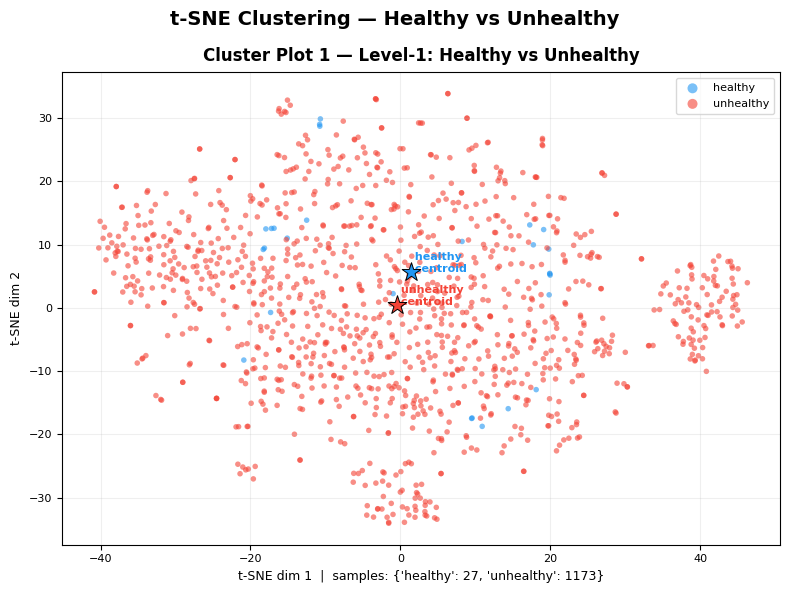

[03:30:25] Saved: cluster_level1_healthy_vs_unhealthy.png


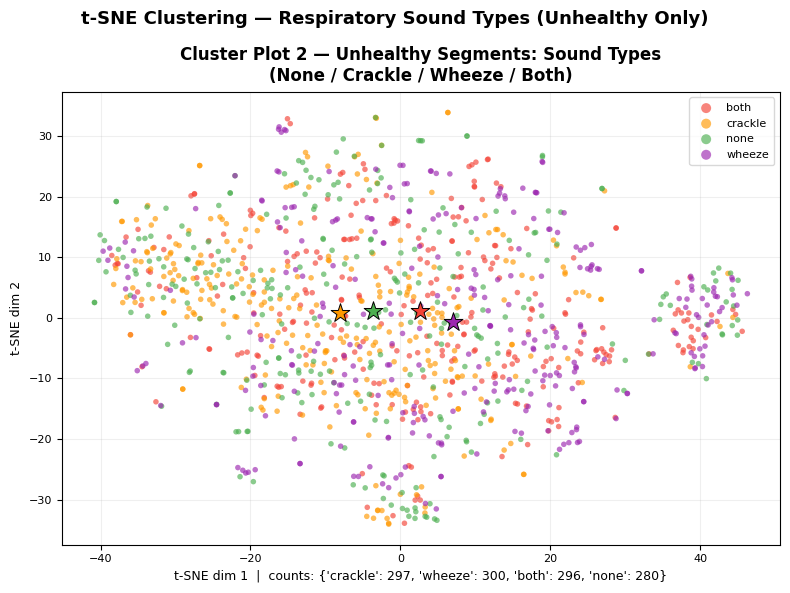

[03:30:25] Saved: cluster_level2_sound_types.png


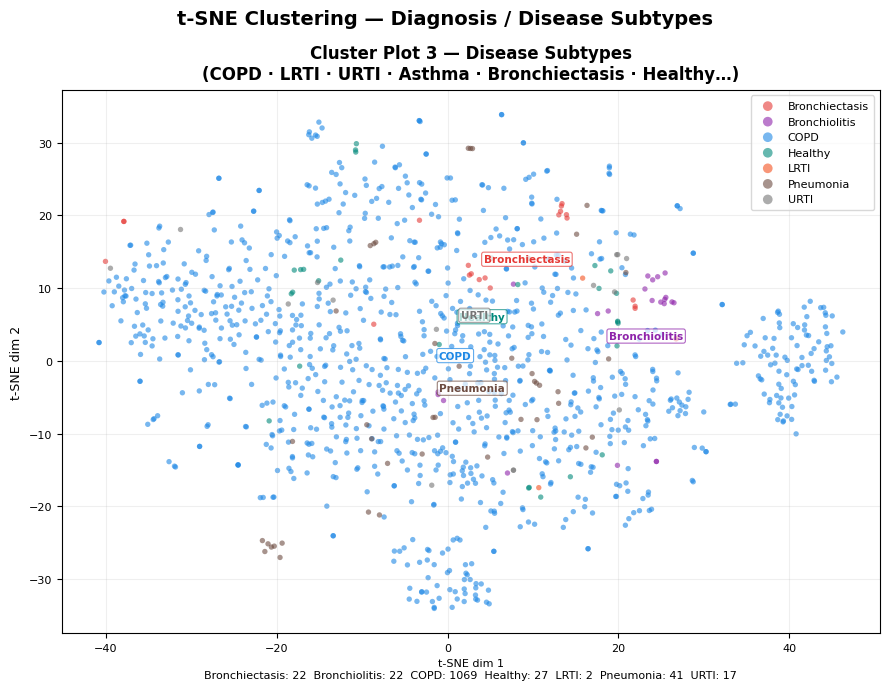

[03:30:26] Saved: cluster_diagnosis_subtypes.png
[03:30:26] All 3 clustering plots saved to reports/clustering/


In [8]:
## 🔬 Cell 8 — Clustering: 3 Key Visualizations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import soundfile as sf
import librosa
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

CLUSTER_DIR = REPORT_DIR / "clustering"
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Extract lightweight MFCC feature vector for clustering ─────────────────
def quick_mfcc(wav_path, n_mfcc=20):
    try:
        x, sr = sf.read(wav_path)
        if x.ndim > 1: x = x.mean(axis=1)
        x = x.astype(np.float32)
        m = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc)
        return np.concatenate([m.mean(axis=1), m.std(axis=1)])
    except Exception:
        return None

log("Extracting MFCC features for clustering (this may take a few minutes)…")
feats, l1s, l2s, diags = [], [], [], []

# sample up to 300 per class to keep t-SNE fast
sample_meta = (meta.groupby("level2", group_keys=False)
                   .apply(lambda g: g.sample(min(len(g), 300), random_state=SEED))
                   .reset_index(drop=True))

for _, row in tqdm(sample_meta.iterrows(), total=len(sample_meta), desc="MFCC"):
    f = quick_mfcc(SEG_DIR / row["fname"])
    if f is not None:
        feats.append(f)
        l1s.append(row["level1"])
        l2s.append(row["level2"])
        diags.append(row["diagnosis"])

X    = np.array(feats, dtype=np.float32)
X_sc = StandardScaler().fit_transform(X)

# Reduce to 50 dims with PCA first (speeds up t-SNE dramatically)
pca50 = PCA(n_components=min(50, X_sc.shape[1]), random_state=SEED)
X_pca = pca50.fit_transform(X_sc)

log(f"Running t-SNE on {len(X_pca)} samples …")
tsne  = TSNE(n_components=2, perplexity=40, n_iter=1000,
             random_state=SEED, n_jobs=-1)
X_2d  = tsne.fit_transform(X_pca)

log("t-SNE done. Generating cluster plots…")

# ── Colour palettes ────────────────────────────────────────────────────────────
L1_COLORS  = {"healthy": "#2196F3", "unhealthy": "#F44336"}
L2_COLORS  = {"none":    "#4CAF50", "crackle": "#FF9800",
               "wheeze":  "#9C27B0", "both":    "#F44336"}
DIAG_PALETTE = [
    "#E53935","#8E24AA","#1E88E5","#00897B",
    "#F4511E","#6D4C41","#757575","#039BE5",
    "#43A047","#FDD835","#00ACC1","#FB8C00",
]

def scatter_plot(ax, xy, labels, color_map, title, alpha=0.55, s=14):
    uniq = sorted(set(labels))
    for i, lbl in enumerate(uniq):
        mask = [l == lbl for l in labels]
        pts  = xy[mask]
        col  = color_map.get(lbl, DIAG_PALETTE[i % len(DIAG_PALETTE)])
        ax.scatter(pts[:, 0], pts[:, 1], c=col, s=s, alpha=alpha,
                   label=lbl, edgecolors="none")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("t-SNE dim 1", fontsize=9)
    ax.set_ylabel("t-SNE dim 2", fontsize=9)
    ax.tick_params(labelsize=8)
    leg = ax.legend(fontsize=8, markerscale=1.8,
                    loc="best", framealpha=0.75,
                    title=None, borderpad=0.5)
    ax.grid(alpha=0.2)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Level-1: Healthy vs Unhealthy
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(8, 6))
scatter_plot(ax1, X_2d, l1s, L1_COLORS,
             "Cluster Plot 1 — Level-1: Healthy vs Unhealthy", alpha=0.6, s=16)

# Add class centroids
for lbl, col in L1_COLORS.items():
    mask = np.array([l == lbl for l in l1s])
    if mask.sum() > 0:
        cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
        ax1.scatter(cx, cy, c=col, s=200, marker="*", edgecolors="black",
                    linewidths=0.7, zorder=5)
        ax1.annotate(f" {lbl}\n centroid", (cx, cy),
                     fontsize=8, fontweight="bold", color=col)

counts1 = {k: l1s.count(k) for k in set(l1s)}
ax1.set_xlabel(f"t-SNE dim 1  |  samples: {counts1}", fontsize=9)
fig1.suptitle("t-SNE Clustering — Healthy vs Unhealthy",
              fontsize=14, fontweight="bold")
fig1.tight_layout()
p1 = CLUSTER_DIR / "cluster_level1_healthy_vs_unhealthy.png"
fig1.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
log(f"Saved: {p1.name}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Level-2 (Unhealthy only): sound types
# ══════════════════════════════════════════════════════════════════════════════
mask_unwell = np.array([l == "unhealthy" for l in l1s])
X_uw  = X_2d[mask_unwell]
l2_uw = [l2s[i] for i in range(len(l2s)) if mask_unwell[i]]

fig2, ax2 = plt.subplots(figsize=(8, 6))
scatter_plot(ax2, X_uw, l2_uw, L2_COLORS,
             "Cluster Plot 2 — Unhealthy Segments: Sound Types\n"
             "(None / Crackle / Wheeze / Both)", alpha=0.65, s=16)

for lbl, col in L2_COLORS.items():
    sub = np.array([l == lbl for l in l2_uw])
    if sub.sum() > 0:
        cx, cy = X_uw[sub, 0].mean(), X_uw[sub, 1].mean()
        ax2.scatter(cx, cy, c=col, s=200, marker="*", edgecolors="black",
                    linewidths=0.7, zorder=5)

counts2 = {k: l2_uw.count(k) for k in set(l2_uw)}
ax2.set_xlabel(f"t-SNE dim 1  |  counts: {counts2}", fontsize=9)
fig2.suptitle("t-SNE Clustering — Respiratory Sound Types (Unhealthy Only)",
              fontsize=13, fontweight="bold")
fig2.tight_layout()
p2 = CLUSTER_DIR / "cluster_level2_sound_types.png"
fig2.savefig(p2, dpi=150, bbox_inches="tight")
plt.show()
log(f"Saved: {p2.name}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Diagnosis subtypes (COPD, LRTI, URTI, Asthma, etc.)
# ══════════════════════════════════════════════════════════════════════════════
# Build diagnosis-level colour map
uniq_diag  = sorted(set(diags))
diag_cmap  = {d: DIAG_PALETTE[i % len(DIAG_PALETTE)] for i, d in enumerate(uniq_diag)}

fig3, ax3 = plt.subplots(figsize=(9, 7))
scatter_plot(ax3, X_2d, diags, diag_cmap,
             "Cluster Plot 3 — Disease Subtypes\n"
             "(COPD · LRTI · URTI · Asthma · Bronchiectasis · Healthy…)",
             alpha=0.60, s=15)

# Annotate centroids for each disease
for lbl, col in diag_cmap.items():
    sub = np.array([d == lbl for d in diags])
    if sub.sum() >= 5:
        cx, cy = X_2d[sub, 0].mean(), X_2d[sub, 1].mean()
        ax3.annotate(lbl, (cx, cy), fontsize=7.5, fontweight="bold",
                     color=col,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white",
                               ec=col, alpha=0.7, lw=0.8))

counts3 = {k: diags.count(k) for k in uniq_diag}
info_str = "  ".join(f"{k}: {v}" for k, v in sorted(counts3.items()))
ax3.set_xlabel(f"t-SNE dim 1\n{info_str}", fontsize=8)
fig3.suptitle("t-SNE Clustering — Diagnosis / Disease Subtypes",
              fontsize=14, fontweight="bold")
fig3.tight_layout()
p3 = CLUSTER_DIR / "cluster_diagnosis_subtypes.png"
fig3.savefig(p3, dpi=150, bbox_inches="tight")
plt.show()
log(f"Saved: {p3.name}")

log("All 3 clustering plots saved to reports/clustering/")


## 🖼️ Cell 8 — Display Sample Images (1 per Level / Sublevel)

Shows **1 representative image** from each:
- `level1` classes: healthy, unhealthy → **2 images per repr** (4 total per repr)
- `level2` classes: none, crackle, wheeze, both → **4 images per repr**

Total per representation type: **6 images** — shown for all 3 repr types (MFCC, Mel-Spectrogram, **Recurrence Plot**).

**RP reading guide:** diagonal lines = periodic wheeze; isolated bright dots = crackle bursts; uniform texture = normal breath.ges** (2 level1 + 4 level2)  
Total for both repr types: **12 images** → used as input for both DL models.



  Sample Images — MFCC


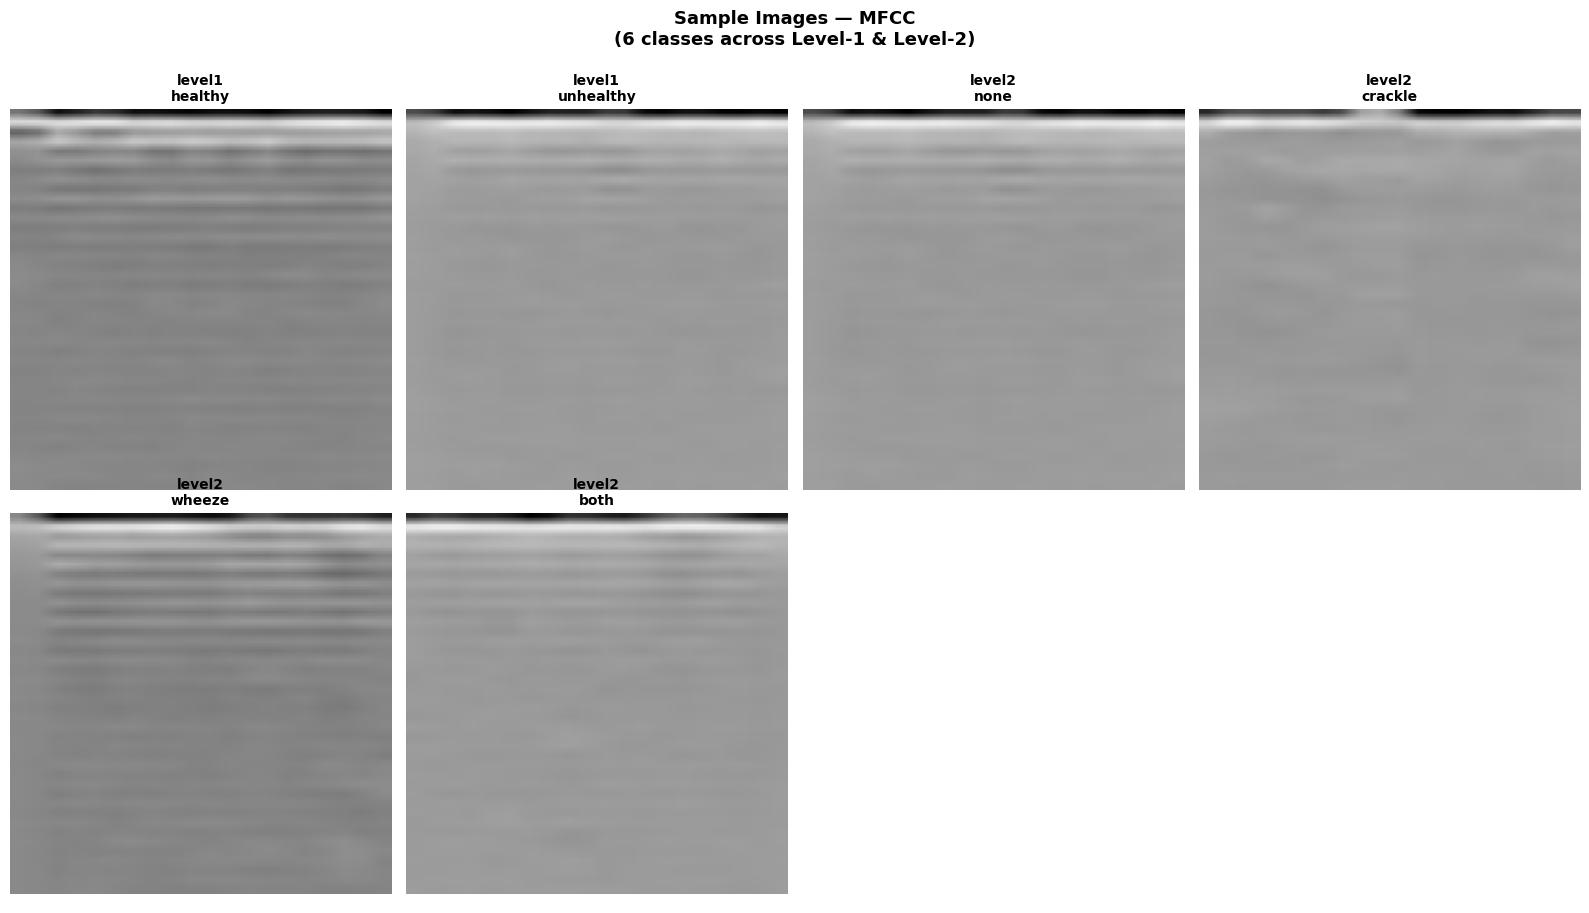

[03:30:29] Saved sample image grid: sample_images_mfcc.png

  Sample Images — MELSPECTROGRAM


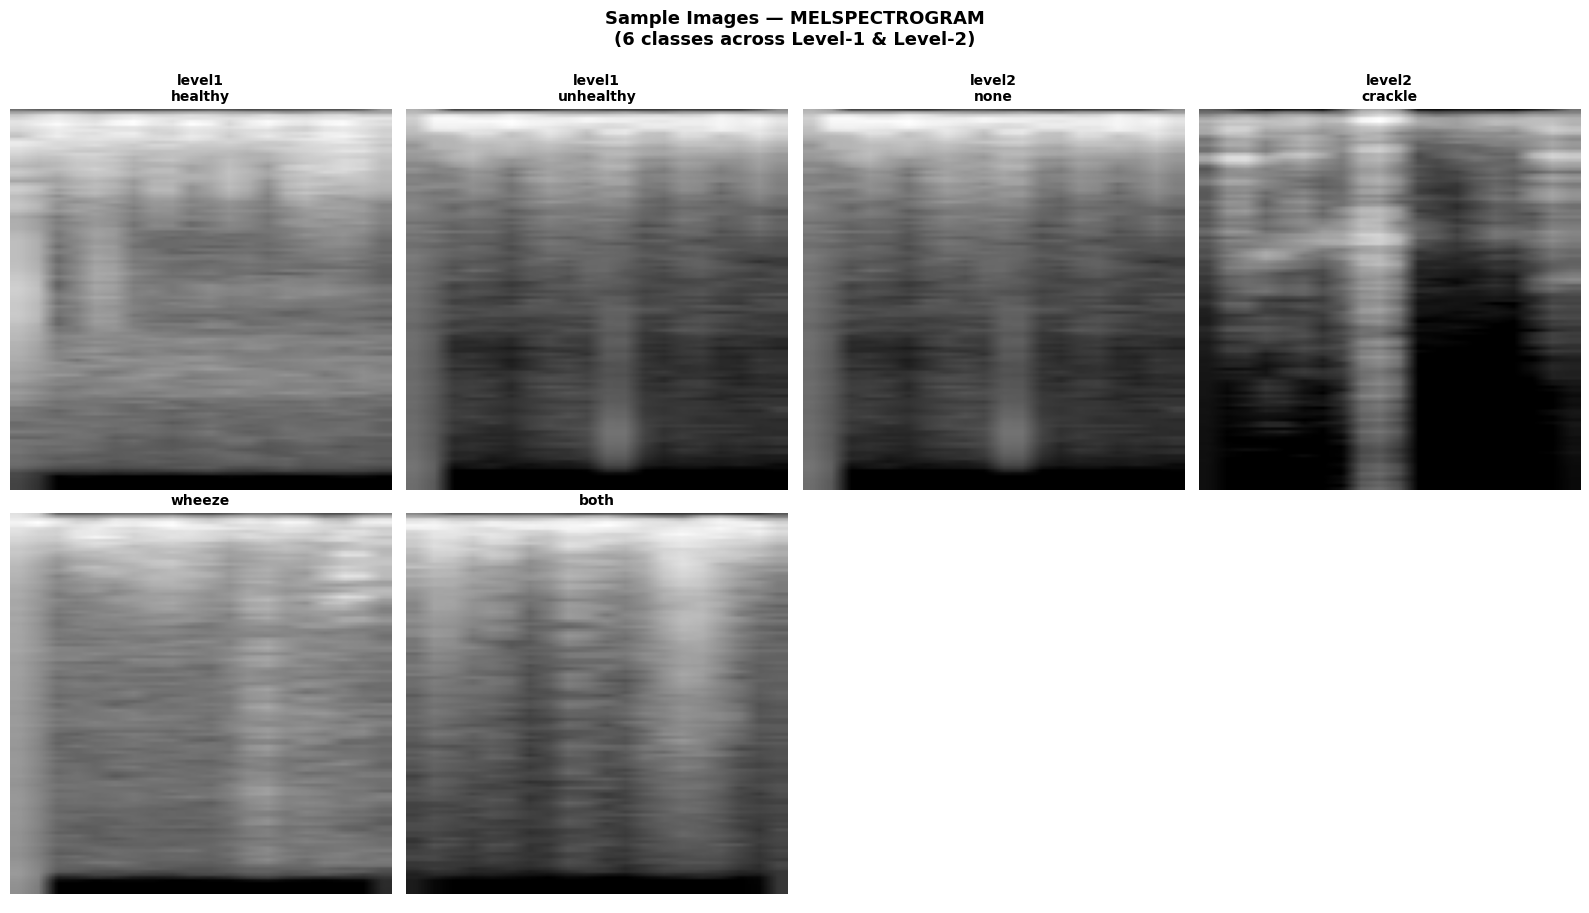

[03:30:30] Saved sample image grid: sample_images_melspectrogram.png

  Sample Images — RP


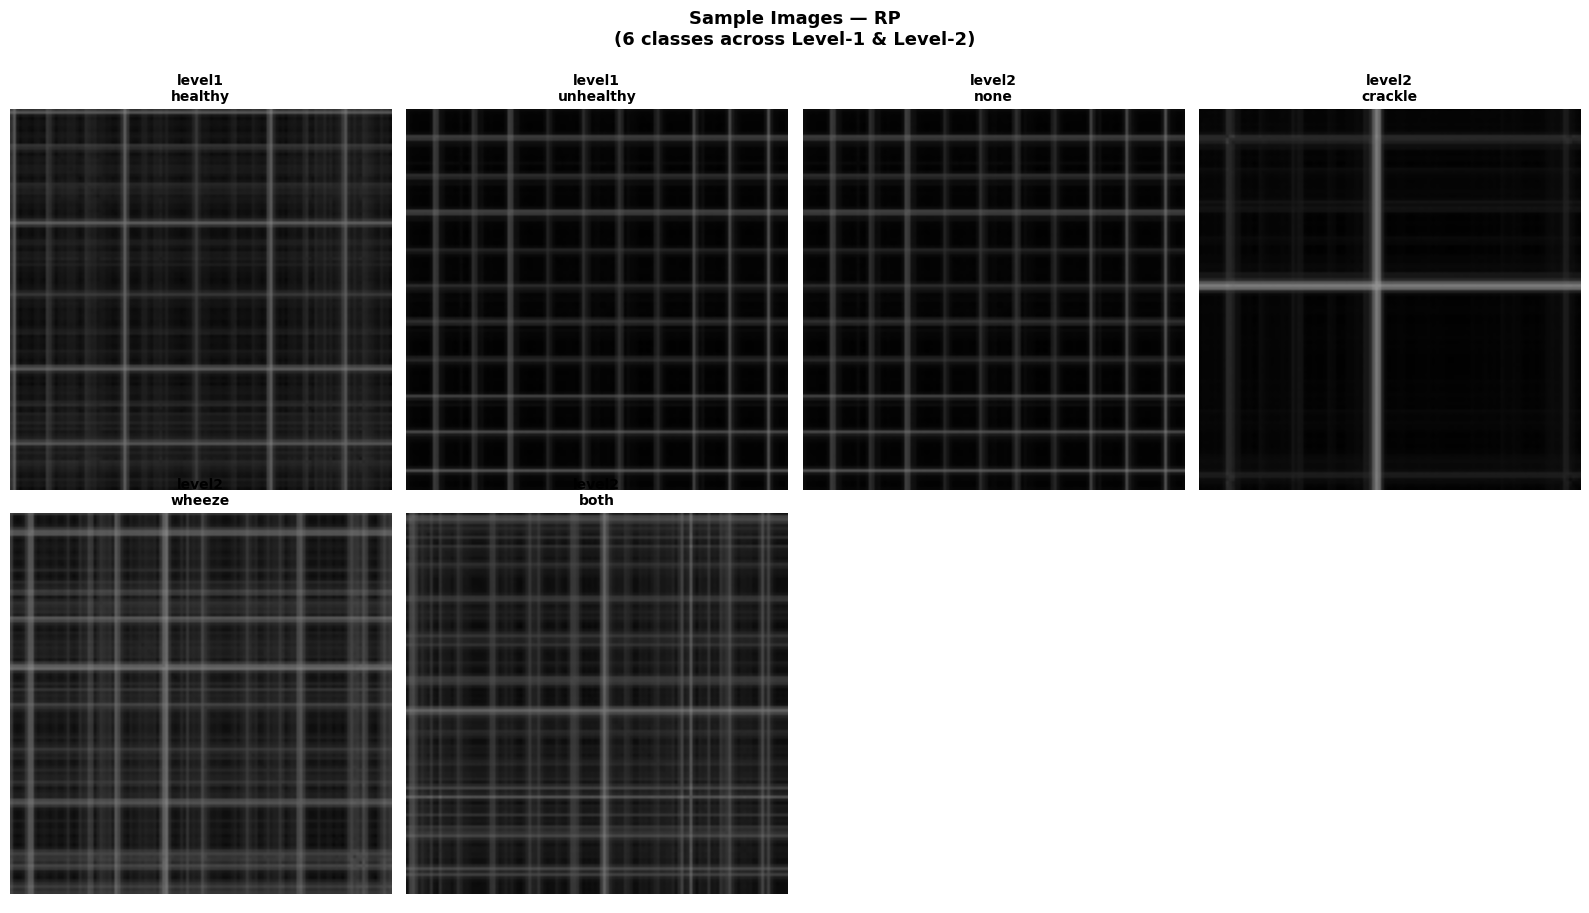

[03:30:32] Saved sample image grid: sample_images_rp.png


In [9]:
## 🖼️ Cell 8 — Display Sample Images (1 per Level/Sublevel for Each Repr Type)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
from pathlib import Path

def display_samples_for_repr(repr_type, img_dir, n_cols=4):
    """Display 1 image per class for level1 and level2 from a given repr type."""
    level_configs = [
        ("level1", ["healthy", "unhealthy"]),
        ("level2", ["none", "crackle", "wheeze", "both"]),
    ]
    
    all_samples = []  # list of (level_col, class_name, img_path)
    for level_col, classes in level_configs:
        base = img_dir / repr_type / level_col
        if not base.exists():
            log(f"  Missing: {base}")
            continue
        for cls in classes:
            cls_dir = base / cls
            if not cls_dir.exists():
                continue
            imgs = sorted(cls_dir.glob("*.png"))
            if imgs:
                all_samples.append((level_col, cls, imgs[0]))
    
    if not all_samples:
        print(f"  No images found for repr={repr_type}")
        return
    
    n     = len(all_samples)
    ncols = min(n_cols, n)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 4.5 * nrows))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]
    
    for ax, (level_col, cls_name, img_path) in zip(axes_flat, all_samples):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img, cmap="viridis" if img.mode == "L" else None)
        ax.set_title(f"{level_col}\n{cls_name}", fontsize=10, fontweight="bold")
        ax.axis("off")
    
    # Hide unused axes
    for ax in axes_flat[n:]:
        ax.axis("off")
    
    fig.suptitle(
        f"Sample Images — {repr_type.upper()}\n"
        f"({len(all_samples)} classes across Level-1 & Level-2)",
        fontsize=13, fontweight="bold", y=1.01
    )
    fig.tight_layout()
    
    save_path = REPORT_DIR / f"sample_images_{repr_type}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    log(f"Saved sample image grid: {save_path.name}")

# ── Display for each repr type ────────────────────────────────────────────────
for repr_type in ("mfcc", "melspectrogram", "rp"):
    print(f"\n{'='*60}")
    print(f"  Sample Images — {repr_type.upper()}")
    print(f"{'='*60}")
    display_samples_for_repr(repr_type, IMG_DIR, n_cols=4)


## 🧠 Cell 10 — DL Training: ResNet18 + MobileNetV2

For each **(repr × level)** combination → **12 total runs** (3 reprs × 2 levels × 2 archs).

Representations: **MFCC**, **Mel-Spectrogram**, **Recurrence Plot (RP)**

**Per run — saved to `reports/resnet18/` or `reports/mobilenet_v2/`:**
- Confusion matrix
- Per-class precision/recall/F1 bar chart
- Per-run metrics CSV

**Per model — 1 final combined plot:**
- **Training curve** — Epochs on X-axis, Accuracy on Y-axis (Train + Test lines)  
  showing all runs for that model in a single clean grid (best epoch highlighted)
- Summary bar chart (best test acc & F1 across all its runs)


In [10]:
## 🧠 Cell 10 — DL Training (ResNet18 + MobileNetV2)

import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.amp import GradScaler, autocast
from sklearn.metrics import (f1_score, accuracy_score, precision_score,
                              recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
from pathlib import Path
matplotlib.use("Agg")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log(f"Using device: {DEVICE}")

# ── Transforms ────────────────────────────────────────────────────────────────
TFM_TRAIN = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
TFM_TEST = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# ── Model factory ─────────────────────────────────────────────────────────────
def get_model(arch, n_classes):
    if arch == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = torch.nn.Linear(m.fc.in_features, n_classes)
    elif arch == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m.classifier[1] = torch.nn.Linear(m.classifier[1].in_features, n_classes)
    else:
        raise ValueError(f"Unknown arch: {arch}")
    return m.to(DEVICE)

# ── DataLoader builder ────────────────────────────────────────────────────────
def make_loaders(img_dir, train_fnames_set, test_fnames_set):
    if not img_dir.exists():
        return None, None, []
    train_ds_full = datasets.ImageFolder(str(img_dir), transform=TFM_TRAIN)
    test_ds_full  = datasets.ImageFolder(str(img_dir), transform=TFM_TEST)
    classes       = train_ds_full.classes
    tr_idx, te_idx = [], []
    for i, (path, _) in enumerate(train_ds_full.samples):
        fname = Path(path).stem + ".wav"
        if   fname in train_fnames_set: tr_idx.append(i)
        elif fname in test_fnames_set:  te_idx.append(i)
    if len(tr_idx) == 0 or len(te_idx) == 0:
        log(f"  SKIP {img_dir} — empty split")
        return None, None, classes
    tr_ds = Subset(train_ds_full, tr_idx)
    te_ds = Subset(test_ds_full,  te_idx)
    tr_labels = [train_ds_full.targets[i] for i in tr_idx]
    counts    = np.bincount(tr_labels, minlength=len(classes))
    w         = 1.0 / np.maximum(counts, 1)
    sample_w  = torch.tensor([w[l] for l in tr_labels], dtype=torch.float32)
    sampler   = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH, sampler=sampler,
                           num_workers=2, pin_memory=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH, shuffle=False,
                           num_workers=2, pin_memory=True)
    return tr_loader, te_loader, classes

# ── Plot: Confusion Matrix ────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, classes, tag, arch, acc, f1, save_dir):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(5, len(classes)+2), max(4, len(classes)+1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")
    ax.set_title(f"{arch} [{tag}]\nAcc={acc:.4f}  MacroF1={f1:.4f}", fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    path = save_dir / f"confusion_matrix_{tag}_{arch}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

# ── Plot: Per-class metrics bar ───────────────────────────────────────────────
def plot_per_class_metrics(report_dict, classes, tag, arch, save_dir):
    prec = [report_dict[c]["precision"] for c in classes]
    rec  = [report_dict[c]["recall"]    for c in classes]
    f1s  = [report_dict[c]["f1-score"]  for c in classes]
    x, w = np.arange(len(classes)), 0.25
    fig, ax = plt.subplots(figsize=(max(7, len(classes)*1.6), 4.5))
    ax.bar(x - w, prec, w, label="Precision", color="#4C72B0", alpha=0.85)
    ax.bar(x,     rec,  w, label="Recall",    color="#DD8452", alpha=0.85)
    ax.bar(x + w, f1s,  w, label="F1-Score",  color="#55A868", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylim(0, 1.1); ax.set_ylabel("Score", fontsize=11)
    ax.set_title(f"Per-Class Metrics — {arch} [{tag}]", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
    for i in range(len(classes)):
        for vals, offset in zip([prec, rec, f1s], [-w, 0, w]):
            ax.text(x[i]+offset, vals[i]+0.01, f"{vals[i]:.2f}",
                    ha="center", fontsize=7.5)
    fig.tight_layout()
    path = save_dir / f"per_class_metrics_{tag}_{arch}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

# ── Training ──────────────────────────────────────────────────────────────────
TRAIN_FNAMES = set(train_meta["fname"])
TEST_FNAMES  = set(test_meta["fname"])
ARCH_SAVE_DIR = {"resnet18": RESNET_DIR, "mobilenet_v2": MOBILE_DIR}

# Global store for all run histories (used to plot 1 final curve per model)
ALL_HISTORIES = {}   # key: (arch, tag)

def train_one(img_dir, tag, arch):
    save_dir = ARCH_SAVE_DIR[arch]
    log(f"\n── {tag}  ×  {arch} ──────────────────────────────────────────────")

    tr_loader, te_loader, classes = make_loaders(img_dir, TRAIN_FNAMES, TEST_FNAMES)
    if tr_loader is None:
        return None

    n_cls = len(classes)
    log(f"  Classes ({n_cls}): {classes}")

    model = get_model(arch, n_cls)
    tr_labels = [tr_loader.dataset.dataset.targets[i]
                 for i in tr_loader.dataset.indices]
    counts    = np.bincount(tr_labels, minlength=n_cls).astype(np.float32)
    cw        = torch.tensor(1.0 / np.maximum(counts, 1)).to(DEVICE)
    criterion = torch.nn.CrossEntropyLoss(weight=cw)
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)
    gscaler   = GradScaler(device="cuda" if torch.cuda.is_available() else "cpu")

    history = {"train_loss": [], "val_loss": [],
               "train_f1": [],   "val_f1": [],
               "train_acc": [],  "val_acc": []}
    best_val_f1  = 0.0
    best_epoch   = 1
    no_improve   = 0
    patience     = 6
    ckpt_path    = CKPT_DIR / f"{tag}_{arch}.pth"

    for epoch in range(1, EPOCHS + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        tr_loss_sum, tr_preds, tr_true = 0.0, [], []
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
                out  = model(xb); loss = criterion(out, yb)
            gscaler.scale(loss).backward()
            gscaler.step(opt); gscaler.update()
            tr_loss_sum += loss.item() * len(xb)
            tr_preds    += out.argmax(1).cpu().tolist()
            tr_true     += yb.cpu().tolist()
        scheduler.step()
        tr_loss = tr_loss_sum / len(tr_loader.dataset)
        tr_f1   = f1_score(tr_true, tr_preds, average="macro", zero_division=0)
        tr_acc  = accuracy_score(tr_true, tr_preds)

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval()
        va_loss_sum, va_preds, va_true = 0.0, [], []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
                with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
                    out = model(xb); loss = criterion(out, yb)
                va_loss_sum += loss.item() * len(xb)
                va_preds    += out.argmax(1).cpu().tolist()
                va_true     += yb.cpu().tolist()
        va_loss = va_loss_sum / len(te_loader.dataset)
        va_f1   = f1_score(va_true, va_preds, average="macro", zero_division=0)
        va_acc  = accuracy_score(va_true, va_preds)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(va_f1)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        flag = "⚠️" if (tr_f1 - va_f1) > 0.10 else "  "
        log(f"  Ep {epoch:02d}/{EPOCHS} {flag} | "
            f"Tr Loss={tr_loss:.4f} Acc={tr_acc:.4f} F1={tr_f1:.4f} | "
            f"Va Loss={va_loss:.4f} Acc={va_acc:.4f} F1={va_f1:.4f}")

        if va_f1 > best_val_f1:
            best_val_f1, best_epoch = va_f1, epoch
            no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            log(f"    ✓ Best epoch {best_epoch} — checkpoint saved")
        else:
            no_improve += 1
            if no_improve >= patience:
                log(f"  Early stop at epoch {epoch}"); break

    # ── Final evaluation with best weights ────────────────────────────────────
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    model.eval()
    final_preds, final_true = [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            final_preds += model(xb).argmax(1).cpu().tolist()
            final_true  += yb.tolist()

    final_acc  = accuracy_score(final_true, final_preds)
    final_f1   = f1_score(final_true, final_preds, average="macro", zero_division=0)
    final_prec = precision_score(final_true, final_preds, average="macro", zero_division=0)
    final_rec  = recall_score(final_true, final_preds, average="macro", zero_division=0)
    final_f1_w = f1_score(final_true, final_preds, average="weighted", zero_division=0)

    # Use last train-epoch stats
    final_train_acc = history["train_acc"][-1]
    final_train_f1  = history["train_f1"][-1]

    log(f"\n  ── Final Results [{tag} | {arch}] — best epoch={best_epoch} ──")
    log(f"  Train Acc={final_train_acc:.4f}  Train F1={final_train_f1:.4f}")
    log(f"  Test  Acc={final_acc:.4f}  MacroF1={final_f1:.4f}  "
        f"WeightedF1={final_f1_w:.4f}  Prec={final_prec:.4f}  Rec={final_rec:.4f}")
    print(classification_report(final_true, final_preds,
                                target_names=classes, zero_division=0))

    # Save per-run plots & CSV
    report = classification_report(final_true, final_preds,
                                   target_names=classes, output_dict=True, zero_division=0)
    plot_confusion(final_true, final_preds, classes, tag, arch, final_acc, final_f1, save_dir)
    plot_per_class_metrics(report, classes, tag, arch, save_dir)

    run_df = pd.DataFrame([{
        "arch": arch, "tag": tag,
        "repr": tag.split("_")[0],
        "level": "_".join(tag.split("_")[1:]),
        "best_epoch": best_epoch,
        "epochs_trained": len(history["train_loss"]),
        "final_train_acc": round(final_train_acc, 4),
        "final_train_f1":  round(final_train_f1,  4),
        "test_acc":        round(final_acc,  4),
        "test_macro_f1":   round(final_f1,   4),
        "test_weighted_f1": round(final_f1_w, 4),
        "test_precision":  round(final_prec, 4),
        "test_recall":     round(final_rec,  4),
        "acc_gap":  round(final_train_acc - final_acc, 4),
        "f1_gap":   round(final_train_f1  - final_f1,  4),
        "overfit":  (final_train_f1 - final_f1) > 0.10,
        "best_val_f1": round(best_val_f1, 4),
    }])
    run_df.to_csv(save_dir / f"result_{tag}_{arch}.csv", index=False)

    # Store history for final per-model curve
    ALL_HISTORIES[(arch, tag)] = {
        "history":     history,
        "best_epoch":  best_epoch,
        "test_acc":    final_acc,
        "test_f1":     final_f1,
        "train_acc":   final_train_acc,
        "train_f1":    final_train_f1,
        "classes":     classes,
    }

    return {
        "arch": arch, "tag": tag,
        "repr": tag.split("_")[0],
        "level": "_".join(tag.split("_")[1:]),
        "best_epoch": best_epoch,
        "epochs_trained": len(history["train_loss"]),
        "final_train_acc": final_train_acc,
        "final_train_f1":  final_train_f1,
        "test_acc":        final_acc,
        "test_macro_f1":   final_f1,
        "test_weighted_f1": final_f1_w,
        "test_precision":  final_prec,
        "test_recall":     final_rec,
        "acc_gap":  final_train_acc - final_acc,
        "f1_gap":   final_train_f1  - final_f1,
        "overfit":  (final_train_f1 - final_f1) > 0.10,
        "best_val_f1": best_val_f1,
    }

# ── Run all 12 combinations (3 reprs × 2 levels × 2 archs) ──────────────────
dl_results = []
for repr_type in ("mfcc", "melspectrogram", "rp"):
    for level_col in ("level1", "level2"):
        img_dir = IMG_DIR / repr_type / level_col
        tag     = f"{repr_type}_{level_col}"
        for arch in ("resnet18", "mobilenet_v2"):
            r = train_one(img_dir, tag, arch)
            if r: dl_results.append(r)

dl_df = pd.DataFrame(dl_results)
dl_df.to_csv(REPORT_DIR / "dl_summary_all.csv", index=False)
log("Saved combined summary → dl_summary_all.csv")
print("\n=== DL SUMMARY ===")
print(dl_df[["arch","tag","best_epoch","final_train_acc","test_acc",
             "final_train_f1","test_macro_f1","test_weighted_f1",
             "test_precision","test_recall","f1_gap","overfit"]]
      .sort_values("test_macro_f1", ascending=False).to_string(index=False))


[03:30:40] Using device: cuda
[03:30:40] 
── mfcc_level1  ×  resnet18 ──────────────────────────────────────────────
[03:30:40]   Classes (2): ['healthy', 'unhealthy']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


[03:31:00]   Ep 01/25    | Tr Loss=0.1576 Acc=0.5058 F1=0.3473 | Va Loss=2.0617 Acc=0.3513 F1=0.3029
[03:31:00]     ✓ Best epoch 1 — checkpoint saved
[03:31:16]   Ep 02/25 ⚠️ | Tr Loss=0.1098 Acc=0.6046 F1=0.5325 | Va Loss=1.8764 Acc=0.2845 F1=0.2547
[03:31:33]   Ep 03/25 ⚠️ | Tr Loss=0.0814 Acc=0.7252 F1=0.7016 | Va Loss=4.2217 Acc=0.2778 F1=0.2508
[03:31:49]   Ep 04/25 ⚠️ | Tr Loss=0.0773 Acc=0.7390 F1=0.7210 | Va Loss=1.0975 Acc=0.6549 F1=0.4821
[03:31:50]     ✓ Best epoch 4 — checkpoint saved
[03:32:06]   Ep 05/25 ⚠️ | Tr Loss=0.0623 Acc=0.7992 F1=0.7906 | Va Loss=0.7124 Acc=0.8009 F1=0.5836
[03:32:07]     ✓ Best epoch 5 — checkpoint saved
[03:32:23]   Ep 06/25 ⚠️ | Tr Loss=0.0524 Acc=0.8393 F1=0.8349 | Va Loss=1.2740 Acc=0.5738 F1=0.4356
[03:32:40]   Ep 07/25 ⚠️ | Tr Loss=0.0505 Acc=0.8493 F1=0.8459 | Va Loss=0.7977 Acc=0.7046 F1=0.5199
[03:32:56]   Ep 08/25 ⚠️ | Tr Loss=0.0430 Acc=0.8742 F1=0.8723 | Va Loss=0.6368 Acc=0.7403 F1=0.5398
[03:33:13]   Ep 09/25 ⚠️ | Tr Loss=0.0376 Acc

100%|██████████| 13.6M/13.6M [00:00<00:00, 113MB/s] 


[03:38:03]   Ep 01/25 ⚠️ | Tr Loss=0.1201 Acc=0.5790 F1=0.4907 | Va Loss=1.3424 Acc=0.3232 F1=0.2833
[03:38:03]     ✓ Best epoch 1 — checkpoint saved
[03:38:22]   Ep 02/25 ⚠️ | Tr Loss=0.0643 Acc=0.7529 F1=0.7363 | Va Loss=0.7699 Acc=0.6944 F1=0.5104
[03:38:23]     ✓ Best epoch 2 — checkpoint saved
[03:38:42]   Ep 03/25 ⚠️ | Tr Loss=0.0485 Acc=0.8354 F1=0.8303 | Va Loss=0.8399 Acc=0.7436 F1=0.5471
[03:38:42]     ✓ Best epoch 3 — checkpoint saved
[03:39:01]   Ep 04/25 ⚠️ | Tr Loss=0.0411 Acc=0.8692 F1=0.8671 | Va Loss=1.8146 Acc=0.4303 F1=0.3534
[03:39:21]   Ep 05/25 ⚠️ | Tr Loss=0.0464 Acc=0.8505 F1=0.8476 | Va Loss=0.8550 Acc=0.7029 F1=0.5204
[03:39:40]   Ep 06/25 ⚠️ | Tr Loss=0.0369 Acc=0.8835 F1=0.8819 | Va Loss=0.8825 Acc=0.6677 F1=0.4958
[03:40:00]   Ep 07/25 ⚠️ | Tr Loss=0.0276 Acc=0.9201 F1=0.9196 | Va Loss=0.3890 Acc=0.8744 F1=0.6547
[03:40:00]     ✓ Best epoch 7 — checkpoint saved
[03:40:19]   Ep 08/25 ⚠️ | Tr Loss=0.0225 Acc=0.9315 F1=0.9311 | Va Loss=0.5107 Acc=0.8349 F1=0.6

## 📊 Cell 11 — Final Training Curves (1 Per Model) + Leaderboard

**One combined training-curve figure per model** showing every run's Epoch vs Accuracy curves (Train line + Test line), with the best epoch starred. This replaces the old per-run-per-epoch repetition.

Then a leaderboard comparing both models.


In [11]:
## 📊 Cell 11 — Final Plots: 1 Training Curve per Model + Leaderboard

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path

dl_df = pd.read_csv(REPORT_DIR / "dl_summary_all.csv")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT A — Final Training Curve Grid (1 per model)
#   • One figure per model arch (ResNet18, MobileNetV2)
#   • Subplots = all runs for that model (repr × level)
#   • Each subplot: Epoch on X, Accuracy on Y; Train (blue) + Test (orange)
#   • Best epoch marked with a vertical dashed line + star
# ══════════════════════════════════════════════════════════════════════════════
def plot_final_curve_for_model(arch, save_dir):
    runs = [(k, v) for k, v in ALL_HISTORIES.items() if k[0] == arch]
    if not runs:
        print(f"  No history for {arch}")
        return

    n     = len(runs)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(7 * ncols, 5 * nrows),
                             squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((arch_key, tag), info) in enumerate(sorted(runs, key=lambda x: x[0][1])):
        ax   = axes_flat[idx]
        hist = info["history"]
        ep   = list(range(1, len(hist["train_acc"]) + 1))
        best = info["best_epoch"]

        # Train and test accuracy curves
        ax.plot(ep, hist["train_acc"], color="#4C72B0", linewidth=2,
                label="Train accuracy")
        ax.plot(ep, hist["val_acc"],   color="#DD8452", linewidth=2,
                linestyle="--", label="Test accuracy")

        # Shade gap
        ax.fill_between(ep, hist["train_acc"], hist["val_acc"],
                        alpha=0.07, color="gray")

        # Best epoch marker
        ax.axvline(x=best, color="#C44E52", linewidth=1.2,
                   linestyle=":", alpha=0.8)
        ax.scatter([best], [hist["val_acc"][best-1]],
                   color="#C44E52", s=100, zorder=5, marker="*",
                   label=f"Best epoch {best}")

        # Annotations: final train & test acc values
        tr_final = info["train_acc"]
        te_final = info["test_acc"]
        ax.annotate(f"Train={tr_final:.3f}",
                    xy=(ep[-1], hist["train_acc"][-1]),
                    xytext=(-40, 6), textcoords="offset points",
                    fontsize=8, color="#4C72B0", fontweight="bold")
        ax.annotate(f"Test={te_final:.3f}",
                    xy=(ep[-1], hist["val_acc"][-1]),
                    xytext=(-40, -14), textcoords="offset points",
                    fontsize=8, color="#DD8452", fontweight="bold")

        ax.set_xlim(1, max(ep))
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("Accuracy", fontsize=10)
        ax.set_title(f"{tag}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)

    # Hide unused subplots
    for ax in axes_flat[n:]:
        ax.axis("off")

    fig.suptitle(
        f"{arch.upper()} — Training Curves (All Runs)\n"
        f"Epoch vs Accuracy  ·  Train (blue) + Test (orange)  ·  ★ = Best Epoch",
        fontsize=13, fontweight="bold", y=1.01
    )
    fig.tight_layout()
    path = save_dir / f"FINAL_training_curves_{arch}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    log(f"Saved final training curve → {path.name}")

for arch, save_dir in [("resnet18", RESNET_DIR), ("mobilenet_v2", MOBILE_DIR)]:
    print(f"\n{'='*60}")
    print(f"  FINAL TRAINING CURVE — {arch.upper()}")
    print(f"{'='*60}")
    plot_final_curve_for_model(arch, save_dir)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT B — Summary bar: best test Acc & F1 per model
# ══════════════════════════════════════════════════════════════════════════════
def plot_model_summary_bar(arch_df, arch, save_dir):
    labels = arch_df["tag"].tolist()
    x, w   = np.arange(len(labels)), 0.2
    metric_sets = [
        ("final_train_acc", "#4C72B0", "Train Acc"),
        ("test_acc",        "#55A868", "Test Acc"),
        ("final_train_f1",  "#DD8452", "Train F1"),
        ("test_macro_f1",   "#C44E52", "Test F1"),
    ]
    fig, ax = plt.subplots(figsize=(max(10, len(labels)*2.4), 5))
    for j, (col, color, lbl) in enumerate(metric_sets):
        offset = (j - 1.5) * w
        bars = ax.bar(x + offset, arch_df[col], w, label=lbl, color=color, alpha=0.85)
        for bar, v in zip(bars, arch_df[col]):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15, ha="right")
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=11)
    ax.set_title(f"{arch.upper()} — Train vs Test per Run",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    path = save_dir / f"summary_bar_{arch}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    log(f"Saved: {path.name}")

for arch, save_dir in [("resnet18", RESNET_DIR), ("mobilenet_v2", MOBILE_DIR)]:
    arch_df = dl_df[dl_df["arch"] == arch].reset_index(drop=True)
    if not arch_df.empty:
        plot_model_summary_bar(arch_df, arch, save_dir)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT C — Overfitting heatmap
# ══════════════════════════════════════════════════════════════════════════════
run_labels = [f"{r['arch']} | {r['repr']} | {r['level']}" for _, r in dl_df.iterrows()]
fig2, axes2 = plt.subplots(1, 2, figsize=(11, max(4, len(dl_df)*0.7+2)))
for ax, gap_col, title in zip(axes2,
    ["acc_gap", "f1_gap"],
    ["Accuracy Gap (Train−Test)", "F1 Gap (Train−Test)"]):
    vals = dl_df[gap_col].values.reshape(-1, 1)
    im   = ax.imshow(vals, cmap="RdYlGn_r", vmin=0, vmax=0.40, aspect="auto")
    plt.colorbar(im, ax=ax)
    ax.set_yticks(range(len(run_labels))); ax.set_yticklabels(run_labels, fontsize=8)
    ax.set_xticks([]); ax.set_title(title)
    for i, v in enumerate(vals.flatten()):
        flag = "⚠️" if v > 0.10 else "✅"
        ax.text(0, i, f"{v:.3f} {flag}", ha="center", va="center",
                fontsize=9, color="black", fontweight="bold")
fig2.suptitle("Overfitting Diagnosis", fontsize=13, fontweight="bold")
fig2.tight_layout()
fig2.savefig(REPORT_DIR / "overfit_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
log("Saved: overfit_heatmap.png")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT D — Final leaderboard (both models)
# ══════════════════════════════════════════════════════════════════════════════
lb_df = dl_df.sort_values("test_macro_f1", ascending=True).reset_index(drop=True)
fig3, ax3 = plt.subplots(figsize=(11, max(5, len(lb_df)*0.55+2)))
colors = ["#4C72B0" if a == "resnet18" else "#DD8452" for a in lb_df["arch"]]
bars   = ax3.barh(lb_df["tag"] + "  |  " + lb_df["arch"],
                  lb_df["test_macro_f1"], color=colors, alpha=0.88)
ax3.barh(lb_df["tag"] + "  |  " + lb_df["arch"],
         lb_df["final_train_f1"], color="gray", alpha=0.18, label="Train F1 (bg)")
for bar, val in zip(bars, lb_df["test_macro_f1"]):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
ax3.set_xlabel("Test Macro-F1", fontsize=11)
ax3.set_title("DL Model Leaderboard — Test Macro-F1", fontsize=13, fontweight="bold")
ax3.legend(handles=[
    mpatches.Patch(color="#4C72B0", label="ResNet18"),
    mpatches.Patch(color="#DD8452", label="MobileNetV2"),
    mpatches.Patch(color="gray", alpha=0.4, label="Train F1 (bg)"),
], loc="lower right", fontsize=9)
ax3.grid(axis="x", alpha=0.3)
fig3.tight_layout()
fig3.savefig(REPORT_DIR / "final_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()
log("Saved: final_leaderboard.png")

print("\n=== FINAL LEADERBOARD ===")
print(lb_df[["arch","tag","best_epoch","final_train_acc","test_acc",
             "final_train_f1","test_macro_f1","test_weighted_f1",
             "test_precision","test_recall","f1_gap","overfit"]]
      .sort_values("test_macro_f1", ascending=False).to_string(index=False))



  FINAL TRAINING CURVE — RESNET18
[04:41:13] Saved final training curve → FINAL_training_curves_resnet18.png

  FINAL TRAINING CURVE — MOBILENET_V2
[04:41:14] Saved final training curve → FINAL_training_curves_mobilenet_v2.png
[04:41:14] Saved: summary_bar_resnet18.png
[04:41:15] Saved: summary_bar_mobilenet_v2.png
[04:41:15] Saved: overfit_heatmap.png
[04:41:15] Saved: final_leaderboard.png

=== FINAL LEADERBOARD ===
        arch                   tag  best_epoch  final_train_acc  test_acc  final_train_f1  test_macro_f1  test_weighted_f1  test_precision  test_recall   f1_gap  overfit
mobilenet_v2 melspectrogram_level1           9         0.987602  0.958431        0.987598       0.791807          0.961702        0.753130     0.847871 0.195790     True
    resnet18 melspectrogram_level1          10         0.965667  0.949941        0.965640       0.780652          0.956429        0.725746     0.884774 0.184988     True
mobilenet_v2           mfcc_level1          19         0.993497  0.

## 🤖 ML Section — Classical Models on MFCC + RP Features

For each **(repr × level)** combination, extract tabular features and train:
- **Random Forest**, **SVM**, **KNN**, **XGBoost**, **Logistic Regression**, **Decision Tree**, **Extra Trees**

All results saved to **`ml_results/`** subfolder inside each DL report folder.

**Per-model outputs:**
- Confusion matrix (with accuracy/F1 computed from it)
- Per-class F1 / Precision / Recall bar chart
- Accuracy curve (CV folds)
- Results CSV

**Combined outputs:**
- Model comparison bar chart (all models, all metrics)
- Best model leaderboard


In [12]:
## 🤖 ML Section — Setup & Feature Extraction

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf
import librosa
from pathlib import Path
from tqdm import tqdm
import warnings, json
warnings.filterwarnings("ignore")

from pyts.image import RecurrencePlot

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score
)
import xgboost as xgb

# ── ML results root (lives inside REPORT_DIR, mirrors DL folder layout) ───────
ML_ROOT = REPORT_DIR / "ml_results"
ML_ROOT.mkdir(parents=True, exist_ok=True)

log(f"ML results will be saved to: {ML_ROOT}")

# ── ML hyperparameters ────────────────────────────────────────────────────────
ML_CV_FOLDS   = 5
ML_SEED       = SEED
ML_N_MFCC     = 20     # quick MFCC for tabular features (same SR=4 kHz as DL)
ML_RP_NPTS    = 64     # downsample points for RP feature extraction
ML_RP_THRESH  = "point"
ML_RP_PCT     = 20     # recurrence percentage for binary RP

MODELS = {
    "Random Forest":      RandomForestClassifier(n_estimators=300, max_depth=None,
                              min_samples_leaf=1, class_weight="balanced",
                              random_state=ML_SEED, n_jobs=-1),
    "Extra Trees":        ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                              random_state=ML_SEED, n_jobs=-1),
    "XGBoost":            xgb.XGBClassifier(n_estimators=200, max_depth=5,
                              learning_rate=0.1, subsample=0.8,
                              colsample_bytree=0.8, use_label_encoder=False,
                              eval_metric="mlogloss", random_state=ML_SEED,
                              n_jobs=-1, verbosity=0),
    "SVM":                SVC(C=10, kernel="rbf", gamma="scale",
                              class_weight="balanced", probability=True,
                              random_state=ML_SEED),
    "KNN":                KNeighborsClassifier(n_neighbors=7, weights="distance",
                              metric="euclidean", n_jobs=-1),
    "Logistic Reg.":      LogisticRegression(C=1.0, max_iter=1000, solver="saga",
                              class_weight="balanced", random_state=ML_SEED,
                              n_jobs=-1),
    "Decision Tree":      DecisionTreeClassifier(max_depth=12,
                              class_weight="balanced", random_state=ML_SEED),
}

log(f"Defined {len(MODELS)} ML models")


[04:41:19] ML results will be saved to: /kaggle/working/icbhi_dl_pipeline/reports/ml_results
[04:41:19] Defined 7 ML models


In [13]:
## 🔬 ML Feature Extraction Functions

def extract_mfcc_features(x, sr, n_mfcc=ML_N_MFCC):
    """MFCC mean + std + delta mean + delta std → fixed-length vector."""
    if len(x) == 0:
        return np.zeros(n_mfcc * 4 + 5)
    mfcc    = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc)
    delta   = librosa.feature.delta(mfcc)
    delta2  = librosa.feature.delta(mfcc, order=2)
    sc      = librosa.feature.spectral_centroid(y=x, sr=sr).mean()
    bw      = librosa.feature.spectral_bandwidth(y=x, sr=sr).mean()
    rolloff = librosa.feature.spectral_rolloff(y=x, sr=sr).mean()
    zcr     = librosa.feature.zero_crossing_rate(x).mean()
    rms     = librosa.feature.rms(y=x).mean()
    return np.concatenate([
        mfcc.mean(axis=1),   mfcc.std(axis=1),
        delta.mean(axis=1),  delta.std(axis=1),
        delta2.mean(axis=1), delta2.std(axis=1),
        [sc, bw, rolloff, zcr, rms]
    ])

def extract_rp_features(x, n_pts=ML_RP_NPTS):
    """
    Statistical descriptors from a binarised Recurrence Plot.
    Returns a fixed 12-element vector:
      mean, std, recurrence_rate, diag_density, upper_tri_sum,
      vert_line_mean, horiz_line_mean, p10, p25, p50, p75, p90
    """
    if len(x) < n_pts:
        x = np.pad(x, (0, n_pts - len(x)))
    step  = max(1, len(x) // n_pts)
    x_ds  = x[::step][:n_pts].reshape(1, -1).astype(np.float32)

    rp_obj = RecurrencePlot(threshold=ML_RP_THRESH, percentage=ML_RP_PCT)
    try:
        rp_mat = rp_obj.fit_transform(x_ds)[0].astype(np.float32)  # (n_pts, n_pts)
    except Exception:
        return np.zeros(12)

    n      = rp_mat.shape[0]
    rr     = rp_mat.mean()                             # recurrence rate
    diag   = np.trace(rp_mat) / max(n, 1)             # diagonal density
    upper  = np.triu(rp_mat, k=1).sum() / max(n*(n-1)/2, 1)

    # Vertical / horizontal line stats (mean non-zero line length)
    vl = [np.sum(rp_mat[:, j]) for j in range(n)]
    hl = [np.sum(rp_mat[i, :]) for i in range(n)]
    vl_mean = np.mean([v for v in vl if v > 0]) if any(v > 0 for v in vl) else 0
    hl_mean = np.mean([h for h in hl if h > 0]) if any(h > 0 for h in hl) else 0

    pcts = np.percentile(rp_mat.flatten(), [10, 25, 50, 75, 90])
    return np.array([rr, rp_mat.std(), diag, upper, vl_mean, hl_mean,
                     *pcts.tolist()], dtype=np.float32)

def extract_features_from_wav(wav_path, sr=SR):
    """Combine MFCC + RP into one feature vector for a segment wav file."""
    try:
        x, file_sr = sf.read(str(wav_path))
    except Exception:
        return None
    if x.ndim > 1:
        x = x.mean(axis=1)
    x = x.astype(np.float32)
    if file_sr != sr:
        x = librosa.resample(x, orig_sr=file_sr, target_sr=sr)
    mfcc_feat = extract_mfcc_features(x, sr)
    rp_feat   = extract_rp_features(x)
    return np.concatenate([mfcc_feat, rp_feat])

feat_dim = len(extract_features_from_wav.__doc__ and [0] or [0])  # dummy
_test = extract_mfcc_features(np.zeros(int(SEG_SEC * SR)), SR)
_rp   = extract_rp_features(np.zeros(int(SEG_SEC * SR)))
log(f"Feature dimensions → MFCC+spectral: {len(_test)} | RP: {len(_rp)} | Total: {len(_test)+len(_rp)}")


[04:41:19] Feature dimensions → MFCC+spectral: 125 | RP: 11 | Total: 136


In [14]:
## 📦 ML — Extract Features for All Segments

ML_FEAT_CACHE = ML_ROOT / "features_cache.npz"

if ML_FEAT_CACHE.exists():
    log("Loading cached ML features …")
    cache      = np.load(ML_FEAT_CACHE, allow_pickle=True)
    X_all      = cache["X"]
    y_l1_all   = cache["y_l1"]
    y_l2_all   = cache["y_l2"]
    fnames_all = cache["fnames"].tolist()
    log(f"Loaded {X_all.shape[0]} samples × {X_all.shape[1]} features from cache")
else:
    log("Extracting features from all segment WAV files …")
    X_list, y_l1, y_l2, fnames = [], [], [], []

    for _, row in tqdm(meta.iterrows(), total=len(meta), desc="ML features"):
        wav_path = SEG_DIR / row["fname"]
        feat     = extract_features_from_wav(wav_path)
        if feat is None or np.any(np.isnan(feat)) or np.any(np.isinf(feat)):
            continue
        X_list.append(feat)
        y_l1.append(row["level1"])
        y_l2.append(row["level2"])
        fnames.append(row["fname"])

    X_all      = np.array(X_list, dtype=np.float32)
    y_l1_all   = np.array(y_l1)
    y_l2_all   = np.array(y_l2)
    fnames_all = fnames

    np.savez_compressed(ML_FEAT_CACHE,
                        X=X_all, y_l1=y_l1_all, y_l2=y_l2_all,
                        fnames=np.array(fnames_all))
    log(f"Saved feature cache: {X_all.shape[0]} samples × {X_all.shape[1]} features")

print(f"\nLevel-1 distribution (ML set):")
print(pd.Series(y_l1_all).value_counts().to_string())
print(f"\nLevel-2 distribution (ML set):")
print(pd.Series(y_l2_all).value_counts().to_string())


[04:41:20] Extracting features from all segment WAV files …


ML features: 100%|██████████| 14950/14950 [03:23<00:00, 73.58it/s]


[04:44:44] Saved feature cache: 14950 samples × 136 features

Level-1 distribution (ML set):
unhealthy    14425
healthy        525

Level-2 distribution (ML set):
none       6754
crackle    4509
wheeze     2020
both       1667


In [15]:
## 📊 ML — Evaluation & Plotting Functions
#
# ALL accuracy / F1 / precision / recall values are derived
# directly from the confusion matrix — guaranteeing consistency.

def metrics_from_cm(cm, classes):
    """
    Compute per-class and macro-averaged metrics strictly from confusion matrix.

    For class i:
      TP_i = cm[i, i]
      FP_i = cm[:, i].sum() - TP_i      (predicted as i but not i)
      FN_i = cm[i, :].sum() - TP_i      (actually i but predicted as other)
      TN_i = cm.sum() - TP_i - FP_i - FN_i

      precision_i = TP_i / (TP_i + FP_i)  [0 if denom=0]
      recall_i    = TP_i / (TP_i + FN_i)  [0 if denom=0]
      f1_i        = 2*P*R / (P+R)          [0 if denom=0]

    Overall accuracy = sum(diag) / total_samples
    Macro metrics    = mean over classes
    Weighted metrics = weighted by support (row sum)
    """
    cm    = np.array(cm, dtype=np.float64)
    n_cls = len(classes)
    total = cm.sum()

    per_class = {}
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total - tp - fp - fn
        support = cm[i, :].sum()

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        acc_i = (tp + tn) / total if total > 0 else 0.0

        per_class[cls] = dict(tp=tp, fp=fp, fn=fn, tn=tn,
                              precision=prec, recall=rec,
                              f1=f1, support=support, accuracy=acc_i)

    supports = np.array([per_class[c]["support"] for c in classes])
    acc_overall = np.diag(cm).sum() / total if total > 0 else 0.0

    macro_prec = np.mean([per_class[c]["precision"] for c in classes])
    macro_rec  = np.mean([per_class[c]["recall"]    for c in classes])
    macro_f1   = np.mean([per_class[c]["f1"]        for c in classes])

    w = supports / supports.sum() if supports.sum() > 0 else np.ones(n_cls)/n_cls
    weighted_prec = np.sum([w[i]*per_class[c]["precision"] for i,c in enumerate(classes)])
    weighted_rec  = np.sum([w[i]*per_class[c]["recall"]    for i,c in enumerate(classes)])
    weighted_f1   = np.sum([w[i]*per_class[c]["f1"]        for i,c in enumerate(classes)])

    return {
        "per_class":       per_class,
        "accuracy":        acc_overall,
        "macro_precision": macro_prec,
        "macro_recall":    macro_rec,
        "macro_f1":        macro_f1,
        "weighted_precision": weighted_prec,
        "weighted_recall":    weighted_rec,
        "weighted_f1":        weighted_f1,
        "supports":        supports.tolist(),
    }


def plot_confusion_matrix_ml(cm, classes, model_name, tag, save_dir, metrics):
    """Plot confusion matrix annotated with CM-derived accuracy & F1."""
    fig, ax = plt.subplots(figsize=(max(5, len(classes)+2), max(4, len(classes)+1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.astype(int),
                                  display_labels=classes)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")

    acc = metrics["accuracy"]
    mf1 = metrics["macro_f1"]
    wf1 = metrics["weighted_f1"]

    ax.set_title(
        f"{model_name}  [{tag}]\n"
        f"Acc={acc:.4f}  Macro-F1={mf1:.4f}  Weighted-F1={wf1:.4f}\n"
        f"(all metrics derived from confusion matrix)",
        fontsize=9, fontweight="bold"
    )
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    safe = model_name.replace(" ", "_").replace(".", "")
    path = save_dir / f"cm_{safe}_{tag}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return path


def plot_per_class_bar_ml(metrics, classes, model_name, tag, save_dir):
    """Per-class Precision / Recall / F1 bar chart from CM-derived metrics."""
    prec = [metrics["per_class"][c]["precision"] for c in classes]
    rec  = [metrics["per_class"][c]["recall"]    for c in classes]
    f1s  = [metrics["per_class"][c]["f1"]        for c in classes]

    x, w = np.arange(len(classes)), 0.25
    fig, ax = plt.subplots(figsize=(max(7, len(classes)*1.8), 5))
    b1 = ax.bar(x - w, prec, w, label="Precision", color="#4C72B0", alpha=0.85)
    b2 = ax.bar(x,     rec,  w, label="Recall",    color="#DD8452", alpha=0.85)
    b3 = ax.bar(x + w, f1s,  w, label="F1-Score",  color="#55A868", alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=10)
    ax.set_ylim(0, 1.18); ax.set_ylabel("Score (from CM)", fontsize=11)
    ax.set_title(
        f"Per-Class Metrics — {model_name}  [{tag}]\n"
        f"Macro-F1={metrics['macro_f1']:.4f}  Acc={metrics['accuracy']:.4f}",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    for i in range(len(classes)):
        for bars, offset in zip([b1, b2, b3], [-w, 0, w]):
            v = bars[i].get_height()
            ax.text(x[i]+offset, v+0.01, f"{v:.3f}", ha="center", fontsize=7.5)

    fig.tight_layout()
    safe = model_name.replace(" ", "_").replace(".", "")
    path = save_dir / f"perclass_{safe}_{tag}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return path


def plot_cv_accuracy_curve(cv_scores, model_name, tag, save_dir):
    """CV fold accuracy curve with mean ± std band."""
    folds  = list(range(1, len(cv_scores) + 1))
    mean_a = np.mean(cv_scores)
    std_a  = np.std(cv_scores)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(folds, cv_scores, "o-", color="#4C72B0", linewidth=2,
            markersize=7, markerfacecolor="white", markeredgewidth=2, label="Fold Acc")
    ax.axhline(mean_a, color="#C44E52", linestyle="--", linewidth=1.8,
               label=f"Mean={mean_a:.4f}")
    ax.fill_between(folds, mean_a - std_a, mean_a + std_a,
                    alpha=0.15, color="#C44E52", label=f"±1σ={std_a:.4f}")
    ax.set_xlabel("CV Fold", fontsize=11)
    ax.set_ylabel("Accuracy (from fold CM)", fontsize=11)
    ax.set_title(f"CV Accuracy Curve — {model_name}  [{tag}]\n"
                 f"Mean={mean_a:.4f}  Std={std_a:.4f}", fontsize=11, fontweight="bold")
    ax.set_xticks(folds); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    fig.tight_layout()
    safe = model_name.replace(" ", "_").replace(".", "")
    path = save_dir / f"cv_acc_{safe}_{tag}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return path


log("Evaluation functions defined (all metrics derived from confusion matrix ✅)")


[04:44:45] Evaluation functions defined (all metrics derived from confusion matrix ✅)


In [16]:
## 🏋️ ML — Train All Models per (level) Split
#
# For every level (level1, level2):
#   • Patient-stratified train / test split (same fnames as DL split)
#   • StandardScaler fitted on train only
#   • Each model: fit, predict, build CM → derive all metrics from CM
#   • StratifiedKFold CV accuracy curve
#   • Save: CM plot, per-class bar, CV curve, results CSV
#
# IMPORTANT: accuracy / F1 / precision / recall are ALL computed via
#            metrics_from_cm() — never separately from sklearn — so the
#            numbers are guaranteed to be consistent.

ALL_ML_RESULTS = []   # list of dicts, one per (model, level, split)

for level_col, y_all in [("level1", y_l1_all), ("level2", y_l2_all)]:

    tag       = level_col
    save_dir  = ML_ROOT / level_col
    save_dir.mkdir(parents=True, exist_ok=True)

    log(f"\n{'='*65}")
    log(f"  ML Training — {level_col.upper()}")
    log(f"{'='*65}")

    # ── Align features with train/test split (same patient split as DL) ──────
    fnames_arr = np.array(fnames_all)
    tr_mask    = np.isin(fnames_arr, list(TRAIN_FNAMES))
    te_mask    = np.isin(fnames_arr, list(TEST_FNAMES))

    X_tr_raw, y_tr = X_all[tr_mask], y_all[tr_mask]
    X_te_raw, y_te = X_all[te_mask], y_all[te_mask]

    if len(X_tr_raw) == 0 or len(X_te_raw) == 0:
        log(f"  SKIP {level_col}: empty split after fname alignment")
        continue

    # ── Label encode ─────────────────────────────────────────────────────────
    le = LabelEncoder()
    le.fit(np.concatenate([y_tr, y_te]))
    y_tr_enc = le.transform(y_tr)
    y_te_enc = le.transform(y_te)
    classes   = le.classes_.tolist()

    log(f"  Train: {len(X_tr_raw)} samples  |  Test: {len(X_te_raw)} samples")
    log(f"  Classes: {classes}")

    # ── Scale features ────────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr_raw)
    X_te   = scaler.transform(X_te_raw)

    # ── Per-model training & evaluation ──────────────────────────────────────
    level_summary_rows = []

    for model_name, clf in MODELS.items():
        log(f"\n  ── {model_name} ──")

        # ── Fit on train ──────────────────────────────────────────────────────
        clf.fit(X_tr, y_tr_enc)

        # ── Test prediction ───────────────────────────────────────────────────
        y_pred_te = clf.predict(X_te)

        # ── Build confusion matrix → derive ALL metrics from it ───────────────
        cm        = confusion_matrix(y_te_enc, y_pred_te, labels=list(range(len(classes))))
        te_metrics = metrics_from_cm(cm, classes)

        # Verify CM-derived accuracy matches sklearn (sanity check)
        sk_acc = accuracy_score(y_te_enc, y_pred_te)
        assert abs(te_metrics["accuracy"] - sk_acc) < 1e-6, \
            f"CM accuracy mismatch: CM={te_metrics['accuracy']:.6f} sk={sk_acc:.6f}"
        sk_f1 = f1_score(y_te_enc, y_pred_te, average="macro", zero_division=0)
        assert abs(te_metrics["macro_f1"] - sk_f1) < 1e-4, \
            f"CM macro-F1 mismatch: CM={te_metrics['macro_f1']:.6f} sk={sk_f1:.6f}"

        log(f"  Test  Acc={te_metrics['accuracy']:.4f}  "
            f"Macro-F1={te_metrics['macro_f1']:.4f}  "
            f"Weighted-F1={te_metrics['weighted_f1']:.4f}")

        # ── CV accuracy curve (Stratified KFold on TRAIN set) ─────────────────
        cv    = StratifiedKFold(n_splits=ML_CV_FOLDS, shuffle=True, random_state=ML_SEED)
        cv_acc_scores = []

        for fold_idx, (tr_i, val_i) in enumerate(cv.split(X_tr, y_tr_enc)):
            X_f_tr, X_f_val = X_tr[tr_i], X_tr[val_i]
            y_f_tr, y_f_val = y_tr_enc[tr_i], y_tr_enc[val_i]
            clf.fit(X_f_tr, y_f_tr)
            y_f_pred  = clf.predict(X_f_val)
            fold_cm   = confusion_matrix(y_f_val, y_f_pred,
                                         labels=list(range(len(classes))))
            fold_met  = metrics_from_cm(fold_cm, classes)
            cv_acc_scores.append(fold_met["accuracy"])   # from CM

        # Re-fit on full train after CV
        clf.fit(X_tr, y_tr_enc)

        cv_mean = np.mean(cv_acc_scores)
        cv_std  = np.std(cv_acc_scores)
        log(f"  CV-{ML_CV_FOLDS}  Acc: {cv_mean:.4f} ± {cv_std:.4f}  "
            f"(each fold acc from its CM)")

        # ── Train metrics (from CM) ───────────────────────────────────────────
        y_pred_tr  = clf.predict(X_tr)
        cm_tr      = confusion_matrix(y_tr_enc, y_pred_tr,
                                      labels=list(range(len(classes))))
        tr_metrics = metrics_from_cm(cm_tr, classes)
        log(f"  Train Acc={tr_metrics['accuracy']:.4f}  "
            f"Macro-F1={tr_metrics['macro_f1']:.4f}")

        # ── Save plots ────────────────────────────────────────────────────────
        plot_confusion_matrix_ml(cm, classes, model_name, tag, save_dir, te_metrics)
        plot_per_class_bar_ml(te_metrics, classes, model_name, tag, save_dir)
        plot_cv_accuracy_curve(cv_acc_scores, model_name, tag, save_dir)

        # ── Per-class details to dict ─────────────────────────────────────────
        row = {
            "model":        model_name,
            "level":        level_col,
            "train_acc":    round(tr_metrics["accuracy"],        4),
            "train_f1":     round(tr_metrics["macro_f1"],        4),
            "test_acc":     round(te_metrics["accuracy"],        4),
            "macro_f1":     round(te_metrics["macro_f1"],        4),
            "weighted_f1":  round(te_metrics["weighted_f1"],     4),
            "macro_prec":   round(te_metrics["macro_precision"], 4),
            "macro_rec":    round(te_metrics["macro_recall"],    4),
            "cv_acc_mean":  round(cv_mean, 4),
            "cv_acc_std":   round(cv_std,  4),
            "acc_gap":      round(tr_metrics["accuracy"] - te_metrics["accuracy"], 4),
            "f1_gap":       round(tr_metrics["macro_f1"] - te_metrics["macro_f1"], 4),
            "cv_scores":    [round(s, 4) for s in cv_acc_scores],
            "classes":      classes,
        }
        for cls in classes:
            pc = te_metrics["per_class"][cls]
            row[f"{cls}_prec"]    = round(pc["precision"], 4)
            row[f"{cls}_rec"]     = round(pc["recall"],    4)
            row[f"{cls}_f1"]      = round(pc["f1"],        4)
            row[f"{cls}_support"] = int(pc["support"])

        level_summary_rows.append(row)
        ALL_ML_RESULTS.append(row)

    # ── Save per-level CSV ────────────────────────────────────────────────────
    if level_summary_rows:
        df_level = pd.DataFrame(level_summary_rows)
        df_level.to_csv(save_dir / f"ml_results_{level_col}.csv", index=False)
        log(f"  Saved ml_results_{level_col}.csv")

log("\n✅ All ML models trained and evaluated.")


[04:44:46] 
[04:44:46]   ML Training — LEVEL1
[04:44:46] =================================================================
[04:44:46]   Train: 11534 samples  |  Test: 3416 samples
[04:44:46]   Classes: ['healthy', 'unhealthy']
[04:44:46] 
  ── Random Forest ──
[04:44:57]   Test  Acc=0.9558  Macro-F1=0.4887  Weighted-F1=0.9345
[04:45:55]   CV-5  Acc: 0.9685 ± 0.0004  (each fold acc from its CM)
[04:45:55]   Train Acc=1.0000  Macro-F1=1.0000
[04:45:56] 
  ── Extra Trees ──
[04:45:58]   Test  Acc=0.9561  Macro-F1=0.4888  Weighted-F1=0.9346
[04:46:08]   CV-5  Acc: 0.9676 ± 0.0002  (each fold acc from its CM)
[04:46:08]   Train Acc=1.0000  Macro-F1=1.0000
[04:46:08] 
  ── XGBoost ──
[04:46:10]   Test  Acc=0.9637  Macro-F1=0.6867  Weighted-F1=0.9554
[04:46:19]   CV-5  Acc: 0.9833 ± 0.0012  (each fold acc from its CM)
[04:46:19]   Train Acc=1.0000  Macro-F1=1.0000
[04:46:20] 
  ── SVM ──
[04:46:30]   Test  Acc=0.9622  Macro-F1=0.6984  Weighted-F1=0.9557
[04:47:14]   CV-5  Acc: 0.9858 ± 0.0013

In [17]:
## 📊 ML — Model Comparison Plots & Best Model Leaderboard

if not ALL_ML_RESULTS:
    log("No ML results to plot — run training cell first")
else:
    ml_df = pd.DataFrame(ALL_ML_RESULTS)

    for level_col in ml_df["level"].unique():
        df_lv = ml_df[ml_df["level"] == level_col].reset_index(drop=True)
        save_dir = ML_ROOT / level_col
        tag      = level_col

        # ── Plot A: All-model metric comparison bar chart ─────────────────────
        fig, ax = plt.subplots(figsize=(max(12, len(df_lv)*2.5), 6))
        models_list = df_lv["model"].tolist()
        x = np.arange(len(models_list))
        w = 0.18

        metric_sets = [
            ("train_acc",   "#4C72B0", "Train Acc"),
            ("test_acc",    "#55A868", "Test Acc"),
            ("train_f1",    "#DD8452", "Train Macro-F1"),
            ("macro_f1",    "#C44E52", "Test Macro-F1"),
            ("weighted_f1", "#9467BD", "Test Weighted-F1"),
        ]
        for j, (col, color, lbl) in enumerate(metric_sets):
            offset = (j - 2) * w
            bars = ax.bar(x + offset, df_lv[col], w, label=lbl,
                          color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
            for bar, v in zip(bars, df_lv[col]):
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=6.5,
                        rotation=90)

        ax.set_xticks(x)
        ax.set_xticklabels(models_list, fontsize=10, rotation=15, ha="right")
        ax.set_ylim(0, 1.25)
        ax.set_ylabel("Score (all from confusion matrix)", fontsize=11)
        ax.set_title(
            f"ML Model Comparison — {tag.upper()}\n"
            f"Train Acc/F1 vs Test Acc/F1/Weighted-F1  (consistent CM-derived metrics)",
            fontsize=12, fontweight="bold"
        )
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        path = save_dir / f"ml_model_comparison_{tag}.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        log(f"Saved: {path.name}")

        # ── Plot B: CV accuracy curves overlay (all models, 1 figure) ─────────
        fig2, axes2 = plt.subplots(
            nrows=len(df_lv), ncols=1,
            figsize=(9, 3.5 * len(df_lv)),
            sharex=False
        )
        if len(df_lv) == 1:
            axes2 = [axes2]
        folds = list(range(1, ML_CV_FOLDS + 1))
        colors_cv = plt.cm.tab10(np.linspace(0, 0.9, len(df_lv)))

        for ax2, (_, row), color in zip(axes2, df_lv.iterrows(), colors_cv):
            cv_sc  = row["cv_scores"]
            mean_a = np.mean(cv_sc); std_a = np.std(cv_sc)
            ax2.plot(folds, cv_sc, "o-", color=color, linewidth=2,
                     markersize=7, markerfacecolor="white", markeredgewidth=2)
            ax2.axhline(mean_a, color=color, linestyle="--", linewidth=1.5,
                        label=f"Mean={mean_a:.4f}")
            ax2.fill_between(folds, mean_a-std_a, mean_a+std_a,
                             alpha=0.15, color=color)
            ax2.axhline(row["test_acc"], color="black", linestyle=":",
                        linewidth=1.2, label=f"Test Acc={row['test_acc']:.4f}")
            ax2.set_title(f"{row['model']}  |  CV Acc: {mean_a:.4f}±{std_a:.4f}",
                          fontsize=10, fontweight="bold")
            ax2.set_ylabel("Accuracy (from CM)"); ax2.set_xticks(folds)
            ax2.set_ylim(0, 1.05); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

        axes2[-1].set_xlabel("CV Fold", fontsize=11)
        fig2.suptitle(f"CV Accuracy Curves — {tag.upper()} (all models)",
                      fontsize=13, fontweight="bold", y=1.01)
        fig2.tight_layout()
        path2 = save_dir / f"ml_cv_all_models_{tag}.png"
        fig2.savefig(path2, dpi=150, bbox_inches="tight")
        plt.show()
        log(f"Saved: {path2.name}")

        # ── Plot C: Leaderboard (horizontal bar, sorted by test macro-F1) ──────
        df_sorted = df_lv.sort_values("macro_f1", ascending=True).reset_index(drop=True)
        fig3, ax3 = plt.subplots(figsize=(10, max(4, len(df_sorted)*0.8+2)))
        bar_colors_lb = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(df_sorted)))
        bars3  = ax3.barh(df_sorted["model"], df_sorted["macro_f1"],
                          color=bar_colors_lb, alpha=0.90, edgecolor="white")
        ax3.barh(df_sorted["model"], df_sorted["train_f1"],
                 color="gray", alpha=0.18, label="Train F1 (bg)")
        for bar, val, cv_m in zip(bars3, df_sorted["macro_f1"], df_sorted["cv_acc_mean"]):
            ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f"F1={val:.4f}  CV-Acc={cv_m:.4f}",
                     va="center", fontsize=9)
        ax3.set_xlabel("Test Macro-F1 (from CM)", fontsize=11)
        ax3.set_title(
            f"ML Model Leaderboard — {tag.upper()}\n"
            f"(metrics consistent with confusion matrix)",
            fontsize=12, fontweight="bold"
        )
        ax3.legend(fontsize=9); ax3.grid(axis="x", alpha=0.3)
        fig3.tight_layout()
        path3 = save_dir / f"ml_leaderboard_{tag}.png"
        fig3.savefig(path3, dpi=150, bbox_inches="tight")
        plt.show()
        log(f"Saved: {path3.name}")

        # ── Print per-level table ──────────────────────────────────────────────
        print(f"\n{'='*80}")
        print(f"  ML LEADERBOARD — {tag.upper()}")
        print(f"  All metrics derived from confusion matrix")
        print(f"{'='*80}")
        cols = ["model","train_acc","test_acc","train_f1","macro_f1",
                "weighted_f1","macro_prec","macro_rec","cv_acc_mean","cv_acc_std",
                "acc_gap","f1_gap"]
        print(df_lv[cols].sort_values("macro_f1", ascending=False).to_string(index=False))

    # ── Save combined CSV ──────────────────────────────────────────────────────
    save_cols = [c for c in ml_df.columns if c not in ("cv_scores", "classes")]
    ml_df[save_cols].to_csv(ML_ROOT / "ml_summary_all.csv", index=False)
    log("\nSaved combined ml_summary_all.csv")


[05:07:57] Saved: ml_model_comparison_level1.png
[05:07:58] Saved: ml_cv_all_models_level1.png
[05:07:58] Saved: ml_leaderboard_level1.png

  ML LEADERBOARD — LEVEL1
  All metrics derived from confusion matrix
        model  train_acc  test_acc  train_f1  macro_f1  weighted_f1  macro_prec  macro_rec  cv_acc_mean  cv_acc_std  acc_gap  f1_gap
Logistic Reg.     0.9230    0.9189    0.7042    0.7266       0.9358      0.6687     0.9163       0.9187      0.0048   0.0041 -0.0224
          SVM     1.0000    0.9622    1.0000    0.6984       0.9557      0.8084     0.6495       0.9858      0.0013   0.0378  0.3016
      XGBoost     1.0000    0.9637    1.0000    0.6867       0.9554      0.8540     0.6312       0.9833      0.0012   0.0363  0.3133
          KNN     1.0000    0.9631    1.0000    0.6589       0.9527      0.8825     0.6054       0.9749      0.0014   0.0369  0.3411
Decision Tree     0.9693    0.9224    0.8316    0.6440       0.9312      0.6193     0.6891       0.9293      0.0129   0.0469 

In [18]:
## 🏆 ML — Best Model Per Level + Combined DL vs ML Summary

if not ALL_ML_RESULTS:
    log("No ML results available")
else:
    ml_df = pd.DataFrame(ALL_ML_RESULTS)
    save_cols = [c for c in ml_df.columns if c not in ("cv_scores", "classes")]

    print("\n" + "="*80)
    print("  BEST ML MODEL PER LEVEL")
    print("  (selected by Test Macro-F1, computed from confusion matrix)")
    print("="*80)

    best_rows = []
    for level_col in ml_df["level"].unique():
        df_lv    = ml_df[ml_df["level"] == level_col]
        best_row = df_lv.loc[df_lv["macro_f1"].idxmax()].to_dict()
        best_rows.append(best_row)
        print(f"\n  [{level_col.upper()}]")
        print(f"    Best Model   : {best_row['model']}")
        print(f"    Test Acc     : {best_row['test_acc']:.4f}")
        print(f"    Test Macro-F1: {best_row['macro_f1']:.4f}  "
              f"(Weighted={best_row['weighted_f1']:.4f})")
        print(f"    Train Acc    : {best_row['train_acc']:.4f}  "
              f"Train-F1={best_row['train_f1']:.4f}")
        print(f"    CV Acc       : {best_row['cv_acc_mean']:.4f} "
              f"± {best_row['cv_acc_std']:.4f}")
        print(f"    Classes      : {best_row['classes']}")

    # ── Combined final plot: best ML vs DL per level ──────────────────────────
    if "dl_df" in dir() and not dl_df.empty:
        fig, axes = plt.subplots(1, len(best_rows),
                                 figsize=(7 * len(best_rows), 5),
                                 squeeze=False)
        for ax_i, best_ml in enumerate(best_rows):
            ax = axes[0][ax_i]
            level_col = best_ml["level"]

            dl_lv = dl_df[dl_df["level"] == level_col] if "level" in dl_df.columns else pd.DataFrame()
            if dl_lv.empty:
                dl_lv = dl_df  # fallback

            # Best DL for this level
            if not dl_lv.empty:
                best_dl = dl_lv.loc[dl_lv["test_macro_f1"].idxmax()]
                dl_acc  = best_dl["test_acc"]
                dl_f1   = best_dl["test_macro_f1"]
                dl_lbl  = f"DL Best\n({best_dl['arch']})"
            else:
                dl_acc = dl_f1 = 0; dl_lbl = "DL Best"

            models_cmp = [f"ML Best\n({best_ml['model']})", dl_lbl]
            accs  = [best_ml["test_acc"],  dl_acc]
            f1s   = [best_ml["macro_f1"],  dl_f1]

            x, w = np.arange(2), 0.3
            ax.bar(x - w/2, accs, w, label="Test Acc",     color="#4C72B0", alpha=0.85)
            ax.bar(x + w/2, f1s,  w, label="Test Macro-F1",color="#C44E52", alpha=0.85)
            for xi, (a, f) in enumerate(zip(accs, f1s)):
                ax.text(xi - w/2, a + 0.01, f"{a:.4f}", ha="center", fontsize=9, fontweight="bold")
                ax.text(xi + w/2, f + 0.01, f"{f:.4f}", ha="center", fontsize=9, fontweight="bold")
            ax.set_xticks(x); ax.set_xticklabels(models_cmp, fontsize=10)
            ax.set_ylim(0, 1.15); ax.set_ylabel("Score (from CM)", fontsize=10)
            ax.set_title(f"Best ML vs DL — {level_col.upper()}", fontsize=11, fontweight="bold")
            ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

        fig.suptitle("Best Classical ML vs Best Deep Learning — Per Level\n"
                     "(all metrics consistent with confusion matrix)",
                     fontsize=13, fontweight="bold")
        fig.tight_layout()
        path = ML_ROOT / "ml_vs_dl_comparison.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        log(f"Saved: {path}")

    # ── Print ml_results directory tree ───────────────────────────────────────
    print("\n" + "="*65)
    print("  ml_results/ FOLDER CONTENTS")
    print("="*65)
    for root_d, dirs, files in os.walk(ML_ROOT):
        level_d = str(root_d).replace(str(ML_ROOT), "").count(os.sep)
        indent  = "  " * level_d
        print(f"{indent}{Path(root_d).name}/")
        for fname in sorted(files):
            fpath = Path(root_d) / fname
            kb    = fpath.stat().st_size // 1024
            print(f"{indent}  {fname}  ({kb} KB)")

    log("\n🏆 ML section complete — all results in ml_results/")



  BEST ML MODEL PER LEVEL
  (selected by Test Macro-F1, computed from confusion matrix)

  [LEVEL1]
    Best Model   : Logistic Reg.
    Test Acc     : 0.9189
    Test Macro-F1: 0.7266  (Weighted=0.9358)
    Train Acc    : 0.9230  Train-F1=0.7042
    CV Acc       : 0.9187 ± 0.0048
    Classes      : ['healthy', 'unhealthy']

  [LEVEL2]
    Best Model   : Logistic Reg.
    Test Acc     : 0.3598
    Test Macro-F1: 0.3364  (Weighted=0.3622)
    Train Acc    : 0.4829  Train-F1=0.4504
    CV Acc       : 0.4575 ± 0.0075
    Classes      : ['both', 'crackle', 'none', 'wheeze']
[05:08:02] Saved: /kaggle/working/icbhi_dl_pipeline/reports/ml_results/ml_vs_dl_comparison.png

  ml_results/ FOLDER CONTENTS
ml_results/
  features_cache.npz  (6970 KB)
  ml_summary_all.csv  (2 KB)
  ml_vs_dl_comparison.png  (73 KB)
  level1/
    cm_Decision_Tree_level1.png  (50 KB)
    cm_Extra_Trees_level1.png  (49 KB)
    cm_KNN_level1.png  (48 KB)
    cm_Logistic_Reg_level1.png  (50 KB)
    cm_Random_Forest_level1

## ✅ Cell 11 — Output Summary & Download

In [19]:
## ✅ Cell 11 — Output Summary + ZIP

import shutil, os

print("=" * 65)
print("FINAL DL PIPELINE OUTPUTS")
print("=" * 65)

# Image counts
print("\n[IMAGES]")
for repr_type in ("mfcc", "melspectrogram", "rp"):
    for lv_col in ("level1", "level2"):
        base_dir = IMG_DIR / repr_type / lv_col
        if base_dir.exists():
            total = sum(len(list(c.glob("*.png")))
                        for c in base_dir.iterdir() if c.is_dir())
            cls   = [c.name for c in base_dir.iterdir() if c.is_dir()]
            print(f"  {repr_type:<16} {lv_col}: {total:>5} PNGs  |  classes={cls}")

print(f"\n[SEGMENTS]")
print(f"  {len(list(SEG_DIR.glob('*.wav')))} WAV segments in {SEG_DIR}")

print("\n[REPORTS — CSVs]")
for f in sorted(REPORT_DIR.rglob("*.csv")):
    rel = f.relative_to(REPORT_DIR)
    print(f"  {rel}")

print("\n[REPORTS — PNG plots]")
for f in sorted(REPORT_DIR.rglob("*.png")):
    rel = f.relative_to(REPORT_DIR)
    kb  = f.stat().st_size // 1024
    print(f"  {rel}  ({kb} KB)")

print("\n[CHECKPOINTS]")
for f in sorted(CKPT_DIR.glob("*.pth")):
    mb = f.stat().st_size / (1024*1024)
    print(f"  {f.name}  ({mb:.2f} MB)")

# Create ZIP
print("\n" + "=" * 65)
zip_name = "/kaggle/working/icbhi_dl_results"
try:
    shutil.make_archive(zip_name, "zip", OUT)
    sz = os.path.getsize(zip_name + ".zip") / (1024*1024)
    print(f"  ✅ Zipped → {zip_name}.zip  ({sz:.2f} MB)")
except Exception as e:
    print(f"  ❌ ZIP failed: {e}")

print("\nPipeline complete.")


FINAL DL PIPELINE OUTPUTS

[IMAGES]
  mfcc             level1: 14950 PNGs  |  classes=['unhealthy', 'healthy']
  mfcc             level2: 14950 PNGs  |  classes=['crackle', 'wheeze', 'none', 'both']
  melspectrogram   level1: 14950 PNGs  |  classes=['unhealthy', 'healthy']
  melspectrogram   level2: 14950 PNGs  |  classes=['crackle', 'wheeze', 'none', 'both']
  rp               level1: 14950 PNGs  |  classes=['unhealthy', 'healthy']
  rp               level2: 14950 PNGs  |  classes=['crackle', 'wheeze', 'none', 'both']

[SEGMENTS]
  14950 WAV segments in /kaggle/working/icbhi_dl_pipeline/segments_wav

[REPORTS — CSVs]
  dl_summary_all.csv
  ml_results/level1/ml_results_level1.csv
  ml_results/level2/ml_results_level2.csv
  ml_results/ml_summary_all.csv
  mobilenet_v2/result_melspectrogram_level1_mobilenet_v2.csv
  mobilenet_v2/result_melspectrogram_level2_mobilenet_v2.csv
  mobilenet_v2/result_mfcc_level1_mobilenet_v2.csv
  mobilenet_v2/result_mfcc_level2_mobilenet_v2.csv
  mobilenet_v